<a href="https://colab.research.google.com/github/leticiasdrummond/Modelos-Base/blob/main/Reinforcement_learning_ev_charging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Model 1**

# 新段落

In [24]:
class EVChargingEnvironment:
    def __init__(self, pricing_scheme, load_profile, t_arr, t_dep,
                 soc_0, soc_d, p_max):
        """Initialize the EV charging environment with a specific pricing scheme"""
        self.pricing_scheme = pricing_scheme
        self.load_profile = load_profile
        self.t_arr = t_arr
        self.t_dep = t_dep
        self.soc_0 = soc_0
        self.soc_d = soc_d
        self.p_max = p_max
        # self.alpha_avg is not used in this class's logic after delegating pricing
        self.T = len(load_profile)
        self.n_evs = len(p_max)

        # Additional tracking variables
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0

        # Initialize state variables
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)

    def reset(self):
        """Reset the environment to initial state"""
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0
        return self._get_state()

    def _get_state(self):
        """Get current state representation"""
        return np.concatenate([
            [self.current_time],
            self.current_soc,
            self.charging_status,
            self.t_arr,
            self.t_dep,
            [self.prices[min(self.current_time, self.T-1)]],
            self.waiting_times
        ])

    def calculate_user_satisfaction(self):
        """Calculate user satisfaction based on charging completion and waiting time"""
        satisfaction = 0
        active_evs = 0

        for ev in range(self.n_evs):
            if self.current_time >= self.t_arr[ev]:
                active_evs += 1

                # Charging progress satisfaction
                progress = min(1.0, self.current_soc[ev] / self.soc_d[ev])

                # Waiting time dissatisfaction
                waiting_penalty = 0.05 * self.waiting_times[ev]

                # Price satisfaction (lower prices = higher satisfaction)
                price_satisfaction = 1.0 - (self.prices[min(self.current_time, self.T-1)] - MIN_PRICE) / (MAX_PRICE - MIN_PRICE)

                ev_satisfaction = (0.5 * progress + 0.3 * (1 - waiting_penalty) + 0.2 * price_satisfaction)
                satisfaction += max(0, ev_satisfaction)

        return satisfaction / max(1, active_evs)

    def calculate_grid_impact(self):
        """Calculate impact on grid stability"""
        time_index = min(self.current_time, self.T - 1)
        total_load = self.load_profile[time_index] + np.sum(self.charging_status * self.p_max)
        peak_increase = max(0, total_load - max(self.load_profile))

        # Calculate load variance for the current hour
        start_idx = max(0, time_index - 3)
        end_idx = min(time_index + 1, self.T)
        recent_loads = self.load_profile[start_idx:end_idx]
        load_variance = np.var(recent_loads)

        return -peak_increase - 0.1 * load_variance

    def step(self, action):
        """Execute one time step within the environment"""
        reward = 0
        done = False
        time_index = min(self.current_time, self.T - 1)
        current_load = self.load_profile[time_index]

        # Calculate current price using the selected pricing scheme
        current_price = self.pricing_scheme.calculate_price(
            time_index,
            current_load,
            max(self.load_profile)
        )
        self.prices[time_index] = current_price

        total_charging_load = 0

        # Apply charging actions and calculate rewards
        for ev in range(self.n_evs):
            if action[ev] and self.current_time >= self.t_arr[ev] and self.current_time < self.t_dep[ev]:
                # Check if EV needs charging and hasn't reached target SOC
                if self.current_soc[ev] < self.soc_d[ev]:
                    charging_amount = min(
                        self.p_max[ev],
                        self.soc_d[ev] - self.current_soc[ev]  # Only charge what's needed
                    )

                    self.current_soc[ev] += charging_amount
                    self.charging_status[ev] = 1
                    total_charging_load += charging_amount

                    # Calculate reward components
                    charging_progress = (self.current_soc[ev] - self.soc_0[ev]) / (self.soc_d[ev] - self.soc_0[ev])
                    charging_progress = min(1.0, charging_progress)  # Cap at 100%

                    # Update revenue
                    self.revenue += current_price * charging_amount

                    # Reward for proper charging
                    reward += 50 * charging_progress

                # Penalty for unnecessary charging
                elif self.current_soc[ev] >= self.soc_d[ev]:
                    reward -= 100

            # Update waiting times only if EV needs charging
            if self.current_time >= self.t_arr[ev] and self.current_soc[ev] < self.soc_d[ev]:
                self.waiting_times[ev] += 1
                reward -= 0.5 * self.waiting_times[ev]  # Small penalty for waiting

        # Grid stability reward/penalty
        total_load = current_load + total_charging_load
        if total_load > max(self.load_profile):
            reward -= 200 * (total_load - max(self.load_profile)) / max(self.load_profile)

        # Load balancing reward
        load_variance = np.var([total_load, current_load])
        reward -= 50 * load_variance / max(self.load_profile)

        # Time management reward
        if self.current_time in PEAK_HOURS:
            reward -= 100 * (total_charging_load / sum(self.p_max))

        self.current_time += 1
        if self.current_time >= self.T:
            done = True

            # Final state rewards/penalties
            for ev in range(self.n_evs):
                if self.current_soc[ev] < self.soc_d[ev]:
                    reward -= 500  # Heavy penalty for not reaching target SOC
                elif self.current_soc[ev] > self.soc_d[ev] * 1.1:  # 10% tolerance
                    reward -= 300  # Penalty for overcharging

        # Store metrics
        self.user_satisfaction.append(self.calculate_user_satisfaction())
        self.grid_stability.append(self.calculate_grid_impact())

        return self._get_state(), reward, done

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime, timedelta

# Base data (same as before)
load_profile = np.array([21.354, 18.44, 14.46, 9.22, 10.014, 12.858, 15.866, 15.676, 16.393,
                         17.383, 19.976, 21.445, 27.88, 33.35, 28.618, 28.519, 29.857, 25.588,
                        22.918, 18.096, 17.061, 17.621, 16.875, 17.703])

t_arr = np.array([4, 4, 5, 5, 7, 8, 8, 8, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14])
t_dep = np.array([8, 6, 9, 9, 10, 11, 11, 10, 16, 20, 20, 21, 21, 22, 21, 19, 23, 23, 23, 20, 24, 23, 20, 19])
soc_0 = np.array([0.9, 4.6, 2.3, 0.3, 6.2, 1.4, 5.5, 6.9, 0.5, 6.9, 3.7, 1.9, 5.6, 3.3, 0.6, 2.7, 2.5, 0.1, 0.7, 6.8, 3.2, 7.3, 0.3, 6.8])
soc_d = soc_0 * 0 + 10
p_max = np.array([3.3, 7.5, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3])

# Pricing scheme constants
class PricingConstants:
    PEAK_HOURS = set(range(17, 22))
    BASE_PRICE = 12.0
    MIN_PRICE = 8.0
    MAX_PRICE = 30.0

class PricingScheme:
    """Base class for pricing schemes"""
    def __init__(self, name):
        self.name = name

    def calculate_price(self, time, load, max_load):
        raise NotImplementedError

class FlatRatePricing(PricingScheme):
    """Flat rate pricing scheme"""
    def __init__(self):
        super().__init__("Flat Rate")

    def calculate_price(self, time, load, max_load):
        return PricingConstants.BASE_PRICE

class TimeOfUsePricing(PricingScheme):
    """Traditional Time-of-Use pricing"""
    def __init__(self):
        super().__init__("Time-of-Use")
        self.peak_multiplier = 1.5
        self.off_peak_multiplier = 0.8

    def calculate_price(self, time, load, max_load):
        if time in PricingConstants.PEAK_HOURS:
            price = PricingConstants.BASE_PRICE * self.peak_multiplier
        elif time in range(23, 7):  # Off-peak hours
            price = PricingConstants.BASE_PRICE * self.off_peak_multiplier
        else:
            price = PricingConstants.BASE_PRICE
        return np.clip(price, PricingConstants.MIN_PRICE, PricingConstants.MAX_PRICE)

class DynamicPricing(PricingScheme):
    """Load-based dynamic pricing"""
    def __init__(self):
        super().__init__("Dynamic")

    def calculate_price(self, time, load, max_load):
        load_factor = load / max_load
        time_factor = 1.5 if time in PricingConstants.PEAK_HOURS else 1.0
        price = PricingConstants.BASE_PRICE * load_factor * time_factor
        return np.clip(price, PricingConstants.MIN_PRICE, PricingConstants.MAX_PRICE)

class ProposedPricing(PricingScheme):
    """Our proposed comprehensive pricing scheme"""
    def __init__(self):
        super().__init__("Proposed")
        self.time_slots = {
            'overnight': range(0, 6),
            'morning': range(6, 9),
            'business': range(9, 17),
            'peak': range(17, 21),
            'evening': range(21, 24)
        }
        self.time_multipliers = {
            'overnight': 0.8,
            'morning': 1.0,
            'business': 1.2,
            'peak': 1.5,
            'evening': 1.1
        }

    def calculate_price(self, time, load, max_load):
        # Base time-of-day price
        time_multiplier = self._get_time_multiplier(time)
        base_price = PricingConstants.BASE_PRICE * time_multiplier

        # Load-based adjustment
        load_factor = min(2.0, load / max_load)

        # Demand forecast adjustment (simplified)
        forecast_factor = 1.2 if time in PricingConstants.PEAK_HOURS else 1.0

        # Renewable energy availability (simplified simulation)
        renewable_factor = random.uniform(0.9, 1.1)

        final_price = base_price * load_factor * forecast_factor * renewable_factor
        return np.clip(final_price, PricingConstants.MIN_PRICE, PricingConstants.MAX_PRICE)

    def _get_time_multiplier(self, time):
        for period, hours in self.time_slots.items():
            if time in hours:
                return self.time_multipliers[period]
        return 1.0

In [14]:
class DQLAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95    # discount rate
        self.epsilon = 1.0   # exploration rate
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.98
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(self.state_size,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse',
                     optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
                     metrics=['mae'])
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(0, 2, size=self.action_size)
        act_values = self.model.predict(state.reshape(1, -1), verbose=0)
        return np.round(act_values[0]).astype(int)

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        states = np.array([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.array([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])

        for i in range(len(minibatch)):
            target = rewards[i]
            if not dones[i]:
                target = rewards[i] + self.gamma * np.amax(
                    self.model.predict(next_states[i].reshape(1, -1), verbose=0)[0]
                )
            target_f = self.model.predict(states[i].reshape(1, -1), verbose=0)
            for j in range(self.action_size):
                if actions[i][j] == 1:
                    target_f[0][j] = target
            self.model.fit(states[i].reshape(1, -1), target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [3]:
class EVChargingEnvironment:
    def __init__(self, pricing_scheme, load_profile, t_arr, t_dep,
                 soc_0, soc_d, p_max):
        """Initialize the EV charging environment with a specific pricing scheme"""
        self.pricing_scheme = pricing_scheme
        self.load_profile = load_profile
        self.t_arr = t_arr
        self.t_dep = t_dep
        self.soc_0 = soc_0
        self.soc_d = soc_d
        self.p_max = p_max
        self.T = len(load_profile)
        self.n_evs = len(p_max)

        # Metrics tracking
        self.metrics = {
            'waiting_times': np.zeros(self.n_evs),
            'prices': np.zeros(24),
            'user_satisfaction': [],
            'grid_stability': [],
            'revenue': 0.0,
            'peak_load': 0.0,
            'total_energy': 0.0,
            'charging_events': 0,
            'failed_charges': 0,
            'load_factor': []
        }

        self.reset()

    def reset(self):
        """Reset environment state"""
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)
        self.current_load = self.load_profile.copy()

        # Reset metrics
        self.metrics = {
            'waiting_times': np.zeros(self.n_evs),
            'prices': np.zeros(24),
            'user_satisfaction': [],
            'grid_stability': [],
            'revenue': 0.0,
            'peak_load': max(self.load_profile),
            'total_energy': 0.0,
            'charging_events': 0,
            'failed_charges': 0,
            'load_factor': []
        }

        return self._get_state()

    def _get_state(self):
        """Get current state representation"""
        return np.concatenate([
            [self.current_time],
            self.current_soc,
            self.charging_status,
            self.t_arr,
            self.t_dep,
            [self.metrics['prices'][min(self.current_time, self.T-1)]],
            self.metrics['waiting_times']
        ])

    def calculate_user_satisfaction(self):
        """Calculate user satisfaction based on multiple factors"""
        satisfaction = 0
        active_evs = 0

        for ev in range(self.n_evs):
            if self.current_time >= self.t_arr[ev]:
                active_evs += 1

                # Charging progress satisfaction
                progress = min(1.0, self.current_soc[ev] / self.soc_d[ev])

                # Waiting time dissatisfaction
                waiting_penalty = 0.05 * self.metrics['waiting_times'][ev]

                # Price satisfaction
                current_price = self.metrics['prices'][min(self.current_time, self.T-1)]
                price_satisfaction = 1.0 - (current_price - PricingConstants.MIN_PRICE) / (
                    PricingConstants.MAX_PRICE - PricingConstants.MIN_PRICE)

                # Combined satisfaction
                ev_satisfaction = (
                    0.5 * progress +
                    0.3 * (1 - waiting_penalty) +
                    0.2 * price_satisfaction
                )
                satisfaction += max(0, ev_satisfaction)

        return satisfaction / max(1, active_evs)

    def calculate_grid_impact(self):
        """Calculate impact on grid stability"""
        time_index = min(self.current_time, self.T - 1)
        total_load = self.current_load[time_index]
        base_load = self.load_profile[time_index]

        # Calculate metrics
        peak_ratio = total_load / max(self.load_profile)
        load_factor = np.mean(self.current_load) / max(self.current_load)
        variance = np.var(self.current_load[-min(24, len(self.current_load)):])

        # Combine metrics into single score
        stability_score = (
            -0.4 * max(0, peak_ratio - 1.2)  # Penalize exceeding 120% of base peak
            -0.3 * (1 - load_factor)         # Reward high load factor
            -0.3 * (variance / (max(self.load_profile) ** 2))  # Penalize high variance
        )

        return stability_score

    def step(self, action):
        """Execute one time step within the environment"""
        reward = 0
        done = False
        time_index = min(self.current_time, self.T - 1)

        # Calculate current price using the selected pricing scheme
        current_price = self.pricing_scheme.calculate_price(
            time_index,
            self.current_load[time_index],
            max(self.load_profile)
        )
        self.metrics['prices'][time_index] = current_price

        # Track charging decisions and their impacts
        total_charging_load = 0
        successful_charges = 0

        # Process each EV's charging decision
        for ev in range(self.n_evs):
            if action[ev] and self.current_time >= self.t_arr[ev] and self.current_time < self.t_dep[ev]:
                if self.current_soc[ev] < self.soc_d[ev]:
                    charging_amount = min(
                        self.p_max[ev],
                        self.soc_d[ev] - self.current_soc[ev]
                    )

                    # Check grid capacity
                    potential_load = self.current_load[time_index] + charging_amount
                    if potential_load <= max(self.load_profile) * 1.2:  # Allow 20% over base peak
                        # Successful charging
                        self.current_soc[ev] += charging_amount
                        self.charging_status[ev] = 1
                        total_charging_load += charging_amount
                        successful_charges += 1

                        # Update metrics
                        self.metrics['charging_events'] += 1
                        self.metrics['revenue'] += current_price * charging_amount
                        self.metrics['total_energy'] += charging_amount

                        # Calculate reward components
                        charging_progress = (self.current_soc[ev] - self.soc_0[ev]) / (self.soc_d[ev] - self.soc_0[ev])
                        reward += 50 * min(1.0, charging_progress)
                    else:
                        self.metrics['failed_charges'] += 1
                        reward -= 25  # Penalty for grid constraint violation
                else:
                    reward -= 50  # Penalty for unnecessary charging

            # Update waiting times
            if self.current_time >= self.t_arr[ev] and self.current_soc[ev] < self.soc_d[ev]:
                self.metrics['waiting_times'][ev] += 1
                reward -= 0.5 * self.metrics['waiting_times'][ev]

        # Update load profile and calculate grid impacts
        self.current_load[time_index] += total_charging_load
        self.metrics['peak_load'] = max(self.metrics['peak_load'], self.current_load[time_index])

        # Calculate load factor
        self.metrics['load_factor'].append(
            np.mean(self.current_load) / max(self.current_load)
        )

        # Add grid stability component to reward
        grid_stability = self.calculate_grid_impact()
        reward += 100 * grid_stability

        # Time progression
        self.current_time += 1
        if self.current_time >= self.T:
            done = True

            # Final state evaluation
            for ev in range(self.n_evs):
                final_soc_ratio = self.current_soc[ev] / self.soc_d[ev]
                if final_soc_ratio < 0.95:
                    reward -= 200 * (1 - final_soc_ratio)
                elif final_soc_ratio > 1.05:
                    reward -= 100 * (final_soc_ratio - 1)

        # Update metrics
        self.metrics['user_satisfaction'].append(self.calculate_user_satisfaction())
        self.metrics['grid_stability'].append(grid_stability)

        return self._get_state(), reward, done

In [4]:
pip install seaborn


In [6]:
# Run comparison
comparison = PricingSchemeComparison()
comparison.run_comparison(episodes=5, batch_size=2)

NameError: name 'PricingSchemeComparison' is not defined

In [7]:
class PricingSchemeComparison:
    def __init__(self):
        self.pricing_schemes = [
            FlatRatePricing(),
            TimeOfUsePricing(),
            DynamicPricing(),
            ProposedPricing()
        ]
        self.results = {}

    def run_comparison(self, episodes=10, batch_size=8):
        """Run comparison of all pricing schemes"""
        for scheme in self.pricing_schemes:
            print(f"\nEvaluating {scheme.name} Pricing Scheme...")
            # Pass the required arguments to EVChargingEnvironment
            env = EVChargingEnvironment(scheme, load_profile, t_arr, t_dep, soc_0, soc_d, p_max)
            state_size = len(env.reset())
            action_size = env.n_evs
            agent = DQLAgent(state_size, action_size)

            scheme_metrics = self.train_scheme(env, agent, episodes, batch_size)
            self.results[scheme.name] = scheme_metrics

        self.plot_comparison()
        self.print_summary()

    def train_scheme(self, env, agent, episodes, batch_size):
        """Train agent with specific pricing scheme and collect metrics"""
        episode_metrics = []

        for episode in range(episodes):
            state = env.reset()
            total_reward = 0
            episode_data = {
                'rewards': [],
                'prices': [],
                'load_profile': [],
                'user_satisfaction': [],
                'grid_stability': []
            }

            while True:
                action = agent.act(state)
                next_state, reward, done = env.step(action)

                agent.remember(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward

                # Collect step metrics
                episode_data['rewards'].append(reward)
                episode_data['prices'].append(env.metrics['prices'][env.current_time-1])
                episode_data['load_profile'].append(env.current_load[env.current_time-1])
                episode_data['user_satisfaction'].append(env.metrics['user_satisfaction'][-1])
                episode_data['grid_stability'].append(env.metrics['grid_stability'][-1])

                if done:
                    print(f"Episode: {episode + 1}/{episodes}")
                    print(f"Total Reward: {total_reward:.2f}")
                    print(f"Revenue: ${env.metrics['revenue']:.2f}")
                    print(f"Average User Satisfaction: {np.mean(env.metrics['user_satisfaction']):.2f}")
                    print(f"Average Grid Stability: {np.mean(env.metrics['grid_stability']):.2f}")
                    print(f"Peak Load: {env.metrics['peak_load']:.2f} kW")
                    print(f"Load Factor: {np.mean(env.metrics['load_factor']):.2f}")
                    print("-" * 50)

                    episode_data['final_metrics'] = {
                        'total_reward': total_reward,
                        'revenue': env.metrics['revenue'],
                        'peak_load': env.metrics['peak_load'],
                        'total_energy': env.metrics['total_energy'],
                        'charging_events': env.metrics['charging_events'],
                        'failed_charges': env.metrics['failed_charges'],
                        'avg_satisfaction': np.mean(env.metrics['user_satisfaction']),
                        'avg_grid_stability': np.mean(env.metrics['grid_stability']),
                        'load_factor': np.mean(env.metrics['load_factor'])
                    }
                    episode_metrics.append(episode_data)
                    break

                if len(agent.memory) > batch_size:
                    agent.replay(batch_size)

        return episode_metrics

    def plot_comparison(self):
        """Generate comparative visualizations"""
        # plt.style.use('seaborn') # Removed due to OSError
        metrics_to_plot = {
            'Revenue': lambda x: x['final_metrics']['revenue'],
            'Peak Load': lambda x: x['final_metrics']['peak_load'],
            'User Satisfaction': lambda x: x['final_metrics']['avg_satisfaction'],
            'Grid Stability': lambda x: x['final_metrics']['avg_grid_stability'],
            'Load Factor': lambda x: x['final_metrics']['load_factor']
        }

        fig, axes = plt.subplots(3, 2, figsize=(15, 20))
        fig.suptitle('Pricing Scheme Comparison', fontsize=16)

        for idx, (metric_name, metric_func) in enumerate(metrics_to_plot.items()):
            ax = axes[idx // 2, idx % 2] if idx < 5 else axes[2, 0]

            data = []
            labels = []
            for scheme_name, scheme_results in self.results.items():
                values = [metric_func(episode) for episode in scheme_results]
                data.append(values)
                labels.append(scheme_name)

            ax.boxplot(data, labels=labels)
            ax.set_title(metric_name)
            ax.tick_params(axis='x', rotation=45)

        # Price comparison over 24 hours
        ax = axes[2, 1]
        for scheme_name, scheme_results in self.results.items():
            final_prices = scheme_results[-1]['prices']
            ax.plot(range(24), final_prices, label=scheme_name)

        ax.set_title('24-Hour Price Comparison')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Price ($/kWh)')
        ax.legend()

        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """Print statistical summary of results"""
        print("\nPricing Scheme Comparison Summary")
        print("=" * 50)

        metrics = ['revenue', 'peak_load', 'avg_satisfaction', 'avg_grid_stability', 'load_factor']
        metric_names = ['Revenue ($)', 'Peak Load (kW)', 'User Satisfaction', 'Grid Stability', 'Load Factor']

        summary_data = []
        for scheme_name, scheme_results in self.results.items():
            scheme_summary = {'Pricing Scheme': scheme_name}

            for metric, metric_name in zip(metrics, metric_names):
                values = [episode['final_metrics'][metric] for episode in scheme_results]
                scheme_summary[metric_name] = f"{np.mean(values):.2f} ± {np.std(values):.2f}"

            summary_data.append(scheme_summary)

        df = pd.DataFrame(summary_data)
        print(df.to_string(index=False))

In [22]:
# Run comparison
comparison = PricingSchemeComparison()
comparison.run_comparison(episodes=5, batch_size=2)


Evaluating Flat Rate Pricing Scheme...


TypeError: object of type 'FlatRatePricing' has no len()

**Model 2**

i. Imports and Constats

In [23]:
import numpy as np
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime, timedelta

# Data arrays
load_profile = np.array([21.354, 18.44, 14.46, 9.22, 10.014, 12.858, 15.866, 15.676, 16.393,
                        17.383, 19.976, 21.445, 27.88, 33.35, 28.618, 28.519, 29.857, 25.588,
                        22.918, 18.096, 17.061, 17.621, 16.875, 17.703])

t_arr = np.array([4, 4, 5, 5, 7, 8, 8, 8, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14])
t_dep = np.array([8, 6, 9, 9, 10, 11, 11, 10, 16, 20, 20, 21, 21, 22, 21, 19, 23, 23, 23, 20, 24, 23, 20, 19])
soc_0 = np.array([0.9, 4.6, 2.3, 0.3, 6.2, 1.4, 5.5, 6.9, 0.5, 6.9, 3.7, 1.9, 5.6, 3.3, 0.6, 2.7, 2.5, 0.1, 0.7, 6.8, 3.2, 7.3, 0.3, 6.8])
soc_d = soc_0 * 0 + 10
p_max = np.array([3.3, 7.5, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3])
alpha_avg = 0.95

# Constants for pricing and scheduling
PEAK_HOURS = set(range(17, 22))  # 5 PM to 9 PM
BASE_PRICE = 12.0
PEAK_PRICE_FACTOR = 1.8
MIN_PRICE = 10.0
MAX_PRICE = 30.0

# Reward weights
CHARGING_PROGRESS_WEIGHT = 100
WAITING_PENALTY_WEIGHT = 0.2
GRID_STABILITY_WEIGHT = 100
LOAD_VARIANCE_WEIGHT = 25
PEAK_CHARGING_PENALTY = 50

# Nova seção


**Part 2 - DQL Agent Class:**

In [10]:
class DQLAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95    # discount rate
        self.epsilon = 1.0   # exploration rate
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.98
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(self.state_size,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse',
                     optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
                     metrics=['mae'])
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(0, 2, size=self.action_size)
        act_values = self.model.predict(state.reshape(1, -1), verbose=0)
        return np.round(act_values[0]).astype(int)

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        states = np.array([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.array([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])

        for i in range(len(minibatch)):
            target = rewards[i]
            if not dones[i]:
                target = rewards[i] + self.gamma * np.amax(
                    self.model.predict(next_states[i].reshape(1, -1), verbose=0)[0]
                )
            target_f = self.model.predict(states[i].reshape(1, -1), verbose=0)
            for j in range(self.action_size):
                if actions[i][j] == 1:
                    target_f[0][j] = target
            self.model.fit(states[i].reshape(1, -1), target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


**Part 3 - Environment Class:**

In [11]:
class EVChargingEnvironment:
    def __init__(self, load_profile=load_profile, t_arr=t_arr, t_dep=t_dep,
                 soc_0=soc_0, soc_d=soc_d, p_max=p_max, alpha_avg=alpha_avg):
        """Initialize the EV charging environment"""
        self.load_profile = load_profile
        self.t_arr = t_arr
        self.t_dep = t_dep
        self.soc_0 = soc_0
        self.soc_d = soc_d
        self.p_max = p_max
        self.alpha_avg = alpha_avg
        self.T = len(load_profile)
        self.n_evs = len(p_max)

        # Additional tracking variables
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0

        # Initialize state variables
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)

    def reset(self):
        """Reset the environment to initial state"""
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0
        return self._get_state()

    def _get_state(self):
        """Get current state representation"""
        return np.concatenate([
            [self.current_time],
            self.current_soc,
            self.charging_status,
            self.t_arr,
            self.t_dep,
            [self.prices[min(self.current_time, self.T-1)]],
            self.waiting_times
        ])

    def calculate_price(self, current_load, time_of_day):
        """Calculate dynamic pricing based on load and time of day"""
        base_price = BASE_PRICE

        # Higher prices during peak hours
        peak_factor = PEAK_PRICE_FACTOR if time_of_day in PEAK_HOURS else 1.0

        # Load-based pricing
        load_factor = current_load / max(self.load_profile)
        load_factor = min(2.0, load_factor)

        # Time-of-day pricing
        time_factor = 1.0
        if time_of_day in range(9, 17):  # Business hours
            time_factor = 1.2
        elif time_of_day in PEAK_HOURS:  # Peak hours
            time_factor = 1.5

        price = base_price * peak_factor * load_factor * time_factor
        return np.clip(price, MIN_PRICE, MAX_PRICE)

    def calculate_user_satisfaction(self):
        """Calculate user satisfaction based on charging completion and waiting time"""
        satisfaction = 0
        active_evs = 0

        for ev in range(self.n_evs):
            if self.current_time >= self.t_arr[ev]:
                active_evs += 1

                # Charging progress satisfaction
                progress = min(1.0, self.current_soc[ev] / self.soc_d[ev])

                # Waiting time dissatisfaction
                waiting_penalty = 0.05 * self.waiting_times[ev]

                # Price satisfaction
                current_price = self.prices[min(self.current_time, self.T-1)]
                price_satisfaction = 1.0 - (current_price - MIN_PRICE) / (MAX_PRICE - MIN_PRICE)

                ev_satisfaction = (0.5 * progress + 0.3 * (1 - waiting_penalty) + 0.2 * price_satisfaction)
                satisfaction += max(0, ev_satisfaction)

        return satisfaction / max(1, active_evs)

    def calculate_grid_impact(self):
        """Calculate impact on grid stability"""
        time_index = min(self.current_time, self.T - 1)
        total_load = self.load_profile[time_index] + np.sum(self.charging_status * self.p_max)
        peak_increase = max(0, total_load - max(self.load_profile))

        # Calculate load variance
        start_idx = max(0, time_index - 3)
        end_idx = min(time_index + 1, self.T)
        recent_loads = self.load_profile[start_idx:end_idx]
        load_variance = np.var(recent_loads)

        return -peak_increase - 0.1 * load_variance

    def step(self, action):
        """Execute one time step within the environment"""
        reward = 0
        done = False
        time_index = min(self.current_time, self.T - 1)
        current_load = self.load_profile[time_index]
        base_load = max(self.load_profile)

        # Calculate current price
        current_price = self.calculate_price(current_load, time_index)
        self.prices[time_index] = current_price

        total_charging_load = 0
        successful_charges = 0

        # Apply charging actions and calculate rewards
        for ev in range(self.n_evs):
            if action[ev] and self.current_time >= self.t_arr[ev] and self.current_time < self.t_dep[ev]:
                if self.current_soc[ev] < self.soc_d[ev]:
                    charging_amount = min(
                        self.p_max[ev],
                        self.soc_d[ev] - self.current_soc[ev]
                    )

                    potential_load = current_load + total_charging_load + charging_amount
                    if potential_load <= base_load * 1.2:  # Allow 20% over base load
                        self.current_soc[ev] += charging_amount
                        self.charging_status[ev] = 1
                        total_charging_load += charging_amount
                        successful_charges += 1

                        charging_progress = (self.current_soc[ev] - self.soc_0[ev]) / (self.soc_d[ev] - self.soc_0[ev])
                        charging_progress = min(1.0, charging_progress)
                        reward += CHARGING_PROGRESS_WEIGHT * charging_progress

                        self.revenue += current_price * charging_amount
                    else:
                        reward -= GRID_STABILITY_WEIGHT * 0.5
                else:
                    reward -= CHARGING_PROGRESS_WEIGHT * 0.5

            if self.current_time >= self.t_arr[ev] and self.current_soc[ev] < self.soc_d[ev]:
                self.waiting_times[ev] += 1
                reward -= WAITING_PENALTY_WEIGHT * self.waiting_times[ev]

        # Grid stability rewards/penalties
        total_load = current_load + total_charging_load
        if total_load > base_load:
            excess = (total_load - base_load) / base_load
            reward -= GRID_STABILITY_WEIGHT * excess

        # Load balancing reward
        if successful_charges > 0:
            load_variance = np.var([total_load, current_load])
            reward -= LOAD_VARIANCE_WEIGHT * (load_variance / base_load)

        # Peak hours penalty
        if self.current_time in PEAK_HOURS and total_charging_load > 0:
            peak_ratio = total_charging_load / sum(self.p_max)
            reward -= PEAK_CHARGING_PENALTY * peak_ratio

        self.current_time += 1
        if self.current_time >= self.T:
            done = True

            for ev in range(self.n_evs):
                final_soc_ratio = self.current_soc[ev] / self.soc_d[ev]
                if final_soc_ratio < 0.95:
                    reward -= CHARGING_PROGRESS_WEIGHT * 2 * (1 - final_soc_ratio)
                elif final_soc_ratio > 1.05:
                    reward -= CHARGING_PROGRESS_WEIGHT * (final_soc_ratio - 1)

        self.user_satisfaction.append(self.calculate_user_satisfaction())
        self.grid_stability.append(self.calculate_grid_impact())

        return self._get_state(), reward, done


**Part 4 - Metrics and Visualization Class:**

In [12]:
class ChargingMetrics:
    def __init__(self):
        self.episode_rewards = []
        self.load_profiles = []
        self.final_soc_levels = []
        self.charging_schedules = []
        self.pricing_history = []
        self.user_satisfaction_history = []
        self.grid_stability_history = []
        self.revenue_history = []

    def add_episode_metrics(self, total_reward, load_profile, final_soc, charging_schedule,
                          prices, user_satisfaction, grid_stability, revenue):
        self.episode_rewards.append(total_reward)
        self.load_profiles.append(load_profile)
        self.final_soc_levels.append(final_soc)
        self.charging_schedules.append(charging_schedule)
        self.pricing_history.append(prices)
        self.user_satisfaction_history.append(np.mean(user_satisfaction))
        self.grid_stability_history.append(np.mean(grid_stability))
        self.revenue_history.append(revenue)

    def plot_metrics(self):
        plt.figure(figsize=(20, 15))

        # Plot 1: Learning Curve
        plt.subplot(3, 2, 1)
        plt.plot(self.episode_rewards, 'b-', label='Episode Reward')
        plt.title('Learning Curve')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.grid(True)
        plt.legend()

        # Plot 2: Load Profile
        plt.subplot(3, 2, 2)
        base_load = load_profile
        final_load = self.load_profiles[-1]
        hours = range(24)
        plt.plot(hours, base_load, 'b-', label='Base Load')
        plt.plot(hours, final_load, 'r-', label='Final Load with EV Charging')
        plt.fill_between(hours, base_load, final_load, alpha=0.3)
        plt.title('Load Profile Comparison')
        plt.xlabel('Hour of Day')
        plt.ylabel('Load (kW)')
        plt.legend()
        plt.grid(True)

        # Plot 3: SOC Levels
        plt.subplot(3, 2, 3)
        final_soc = self.final_soc_levels[-1]
        x = range(len(final_soc))
        plt.bar(x, final_soc, alpha=0.8, label='Final SOC')
        plt.bar(x, soc_0, alpha=0.5, label='Initial SOC')
        plt.axhline(y=10, color='r', linestyle='--', label='Target SOC')
        plt.title('State of Charge Levels')
        plt.xlabel('EV Index')
        plt.ylabel('SOC')
        plt.legend()

        # Plot 4: Dynamic Pricing
        plt.subplot(3, 2, 4)
        plt.plot(hours, self.pricing_history[-1], 'g-', marker='o')
        plt.axhline(y=BASE_PRICE, color='r', linestyle='--', label='Base Price')
        plt.fill_between(list(PEAK_HOURS),
                        [MIN_PRICE] * len(PEAK_HOURS),
                        [MAX_PRICE] * len(PEAK_HOURS),
                        alpha=0.2, color='r', label='Peak Hours')
        plt.title('Dynamic Pricing Schedule')
        plt.xlabel('Hour of Day')
        plt.ylabel('Price ($/kWh)')
        plt.legend()
        plt.grid(True)

        # Plot 5: Performance Metrics
        plt.subplot(3, 2, 5)
        episodes = range(len(self.user_satisfaction_history))
        plt.plot(episodes, self.user_satisfaction_history, 'b-', label='User Satisfaction')
        plt.plot(episodes, self.grid_stability_history, 'r-', label='Grid Stability')
        plt.title('Performance Metrics')
        plt.xlabel('Episode')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # Plot 6: Revenue Trend
        plt.subplot(3, 2, 6)
        plt.plot(episodes, self.revenue_history, 'g-', label='Revenue')
        plt.title('Revenue per Episode')
        plt.xlabel('Episode')
        plt.ylabel('Revenue ($)')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # Additional Heatmap for Charging Schedule
        plt.figure(figsize=(15, 8))
        sns.heatmap(self.charging_schedules[-1],
                   cmap='YlOrRd',
                   xticklabels=range(24),
                   yticklabels=range(len(p_max)))
        plt.title('Charging Schedule Heatmap')
        plt.xlabel('Hour of Day')
        plt.ylabel('EV Index')
        plt.show()


**Part 5 - Training Function and Main Execution:**


Episode: 1/10
Total Reward: -63.79
Final Revenue: $1917.94
Average User Satisfaction: 0.77
Average Grid Stability: -32.67

Episode: 2/10
Total Reward: -939.14
Final Revenue: $2078.27
Average User Satisfaction: 0.79
Average Grid Stability: -30.42

Episode: 3/10
Total Reward: -706.53
Final Revenue: $2142.22
Average User Satisfaction: 0.84
Average Grid Stability: -35.44

Episode: 4/10
Total Reward: -1162.87
Final Revenue: $2115.82
Average User Satisfaction: 0.82
Average Grid Stability: -35.30

Episode: 5/10
Total Reward: -1238.69
Final Revenue: $2100.60
Average User Satisfaction: 0.83
Average Grid Stability: -34.65


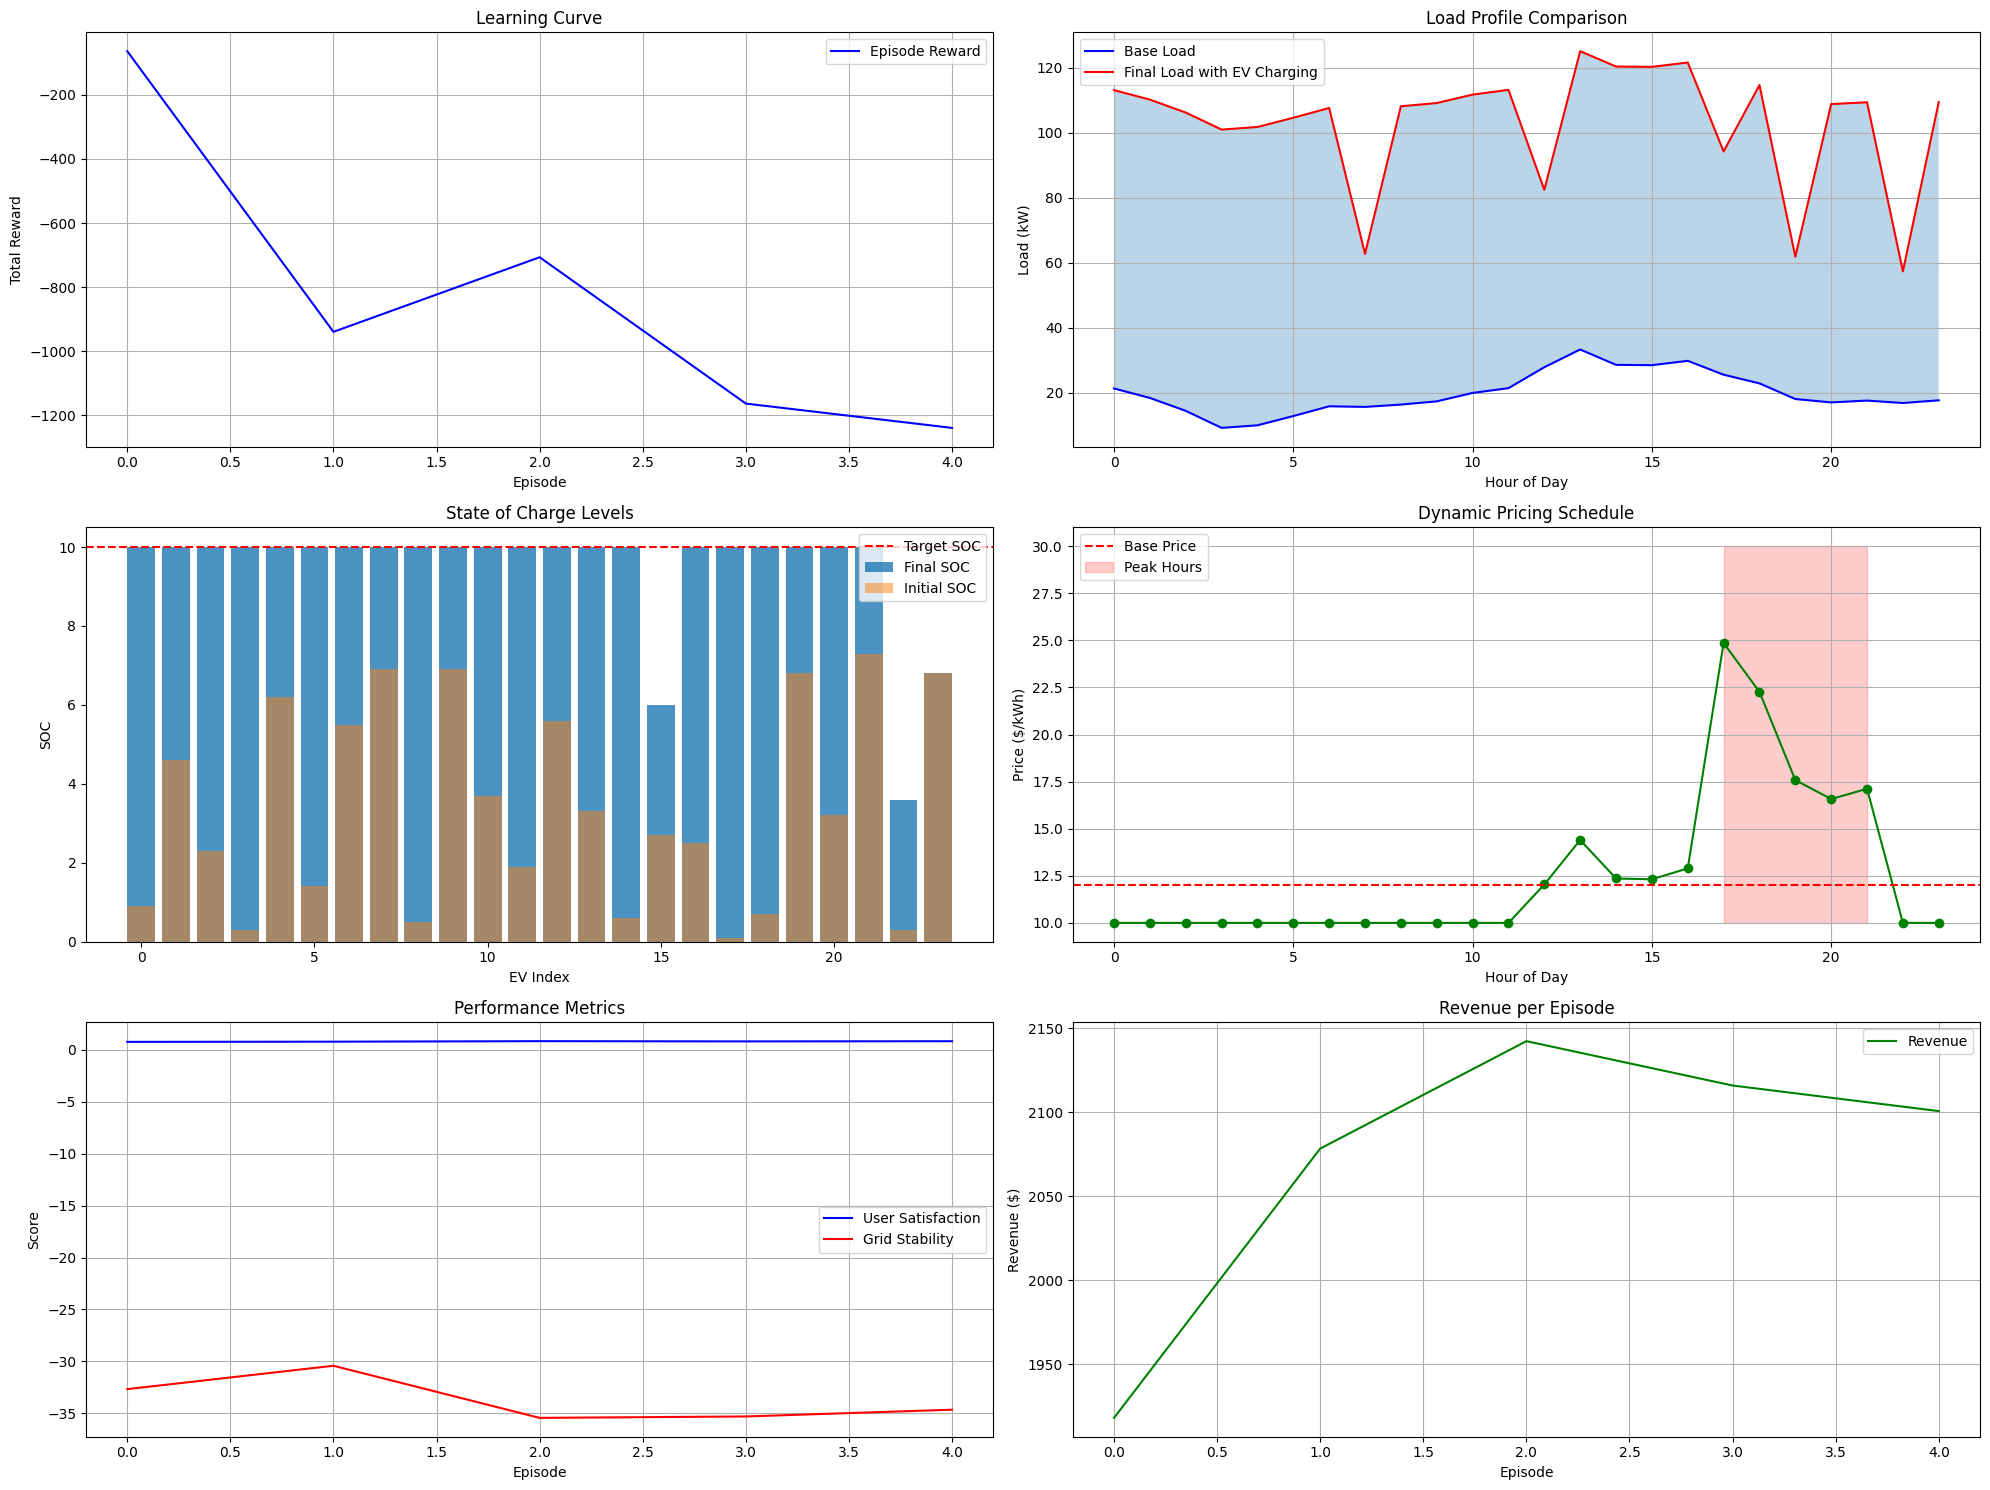

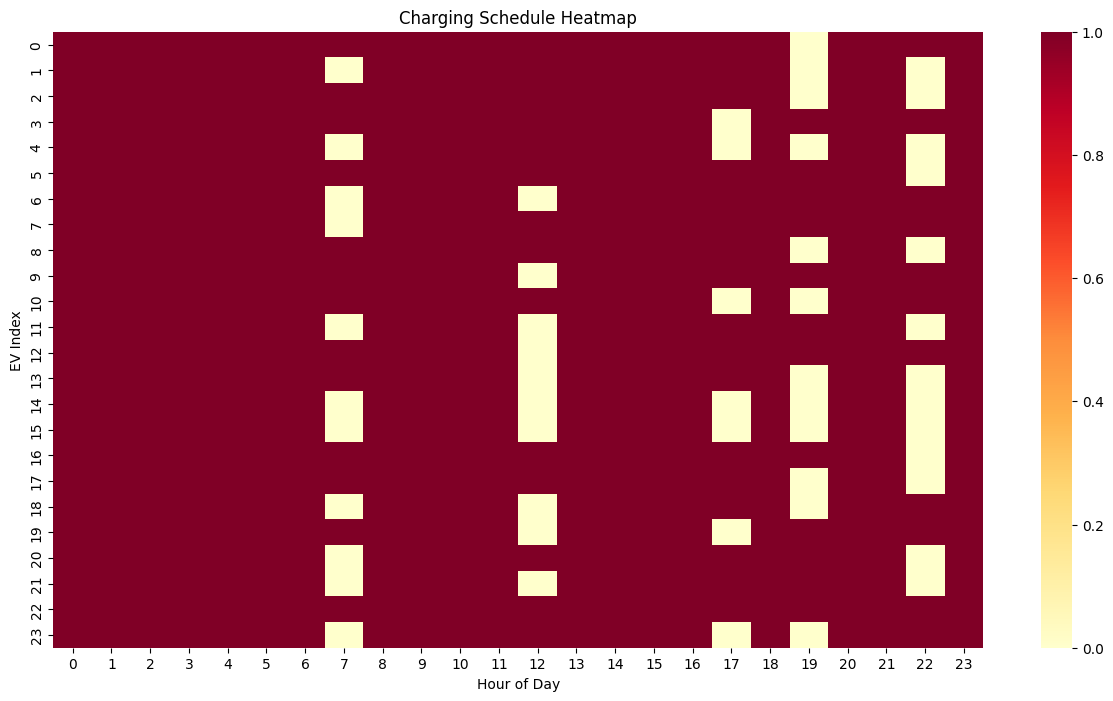


Episode: 6/10
Total Reward: -1573.87
Final Revenue: $2175.63
Average User Satisfaction: 0.83
Average Grid Stability: -35.13

Episode: 7/10
Total Reward: -1589.88
Final Revenue: $2145.83
Average User Satisfaction: 0.84
Average Grid Stability: -35.03

Episode: 8/10
Total Reward: -1889.88
Final Revenue: $2145.83
Average User Satisfaction: 0.84
Average Grid Stability: -35.03

Episode: 9/10
Total Reward: -1358.19
Final Revenue: $2176.07
Average User Satisfaction: 0.84
Average Grid Stability: -34.99

Episode: 10/10
Total Reward: -1538.08
Final Revenue: $2127.08
Average User Satisfaction: 0.84
Average Grid Stability: -36.10


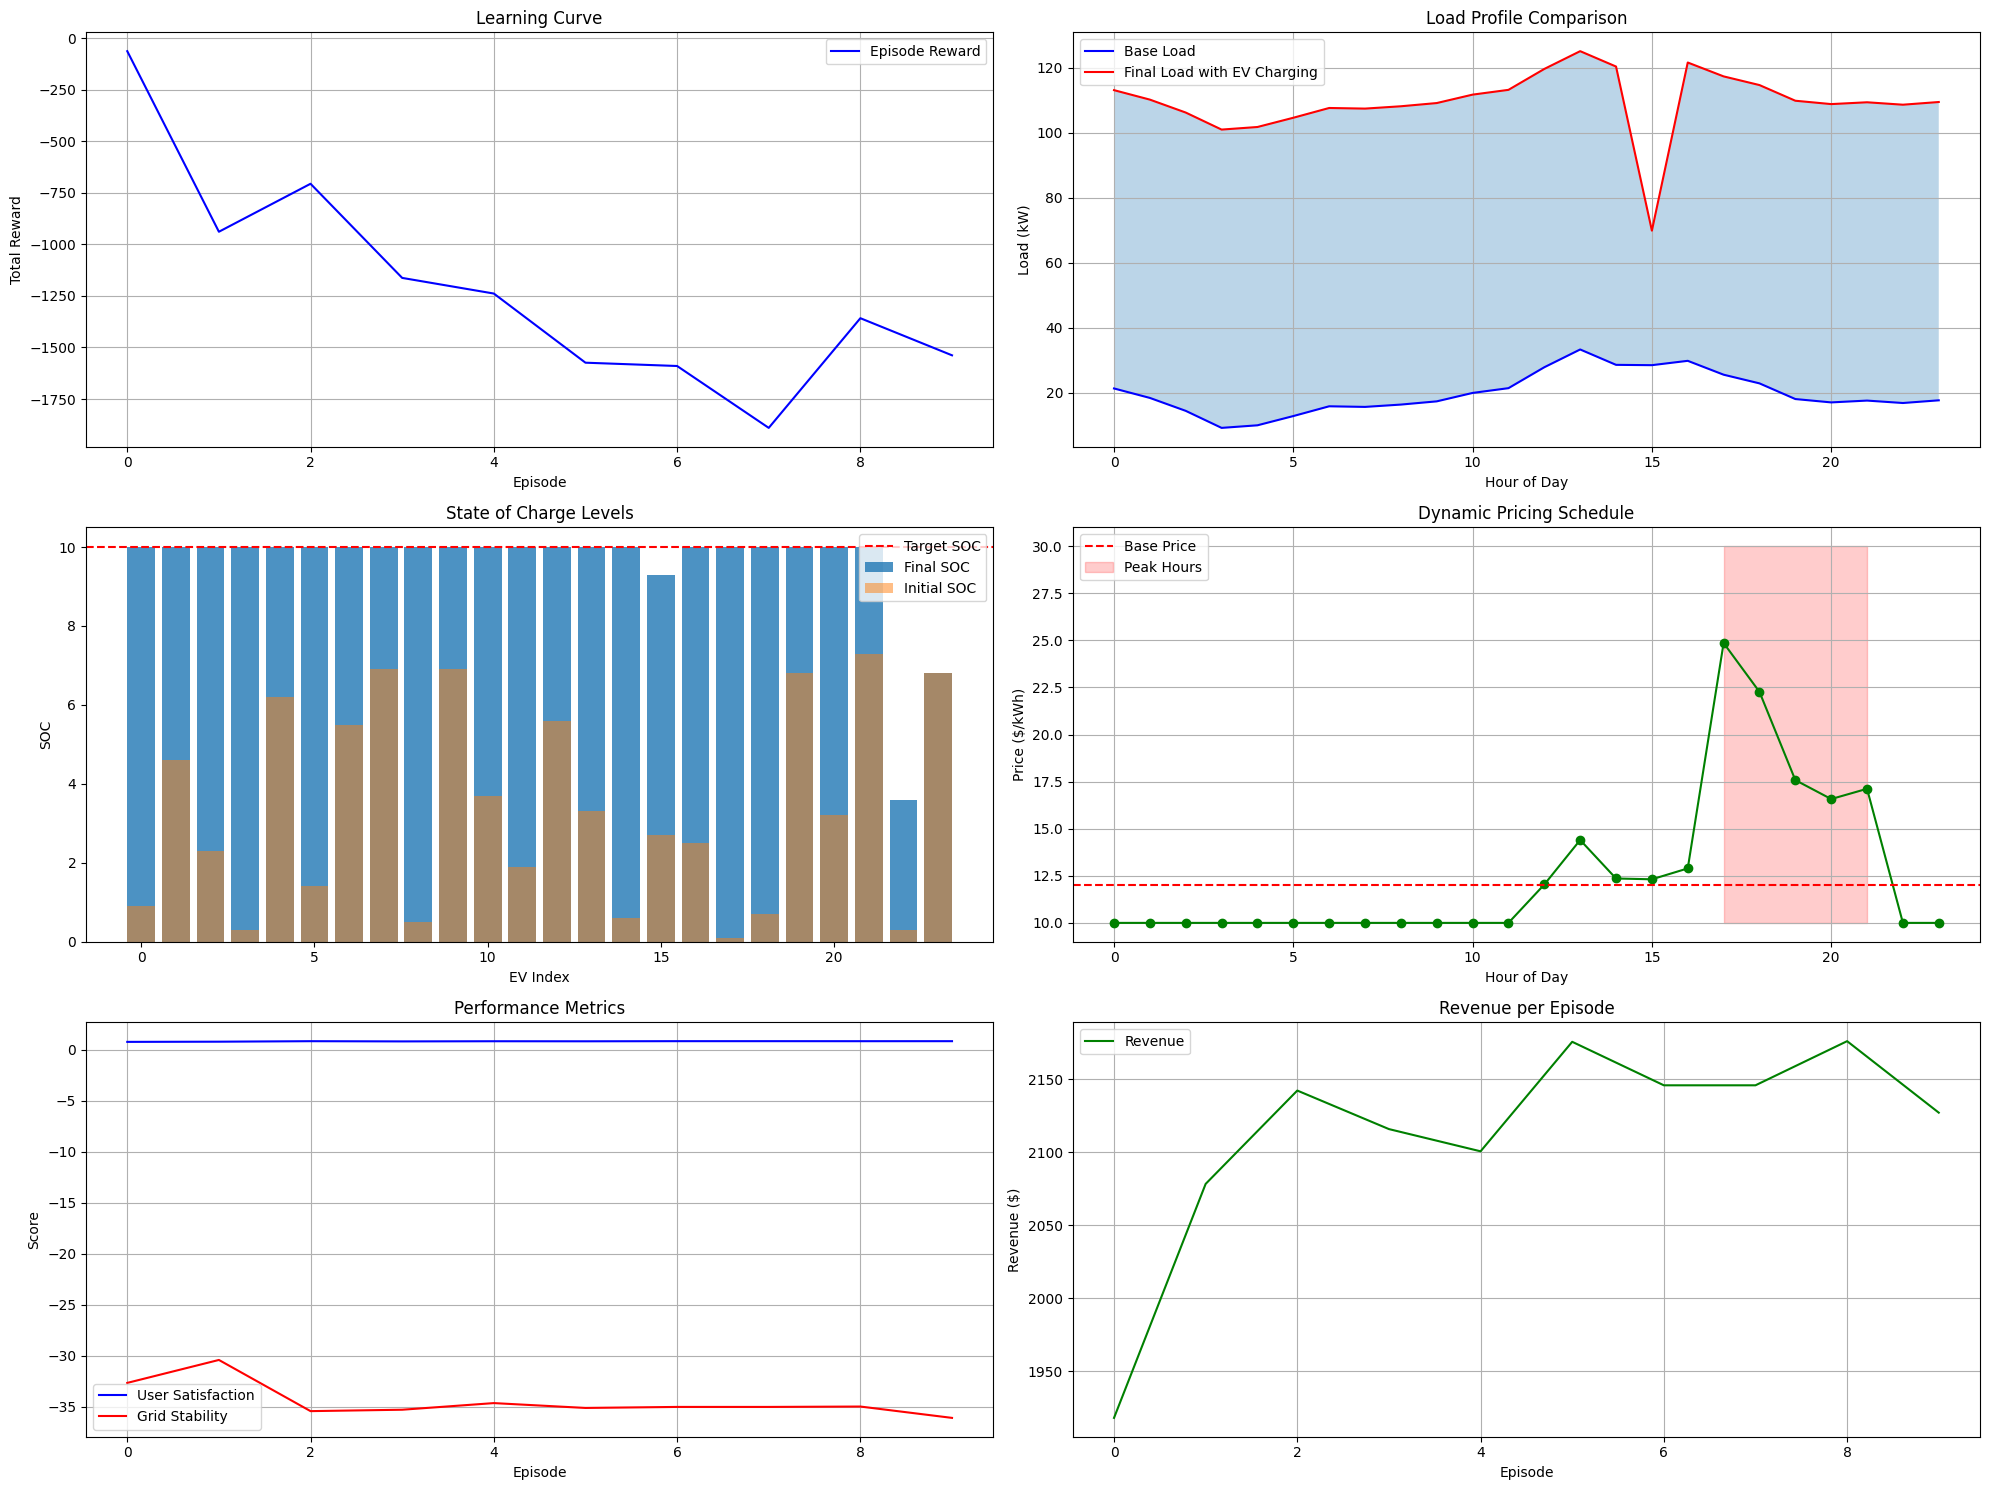

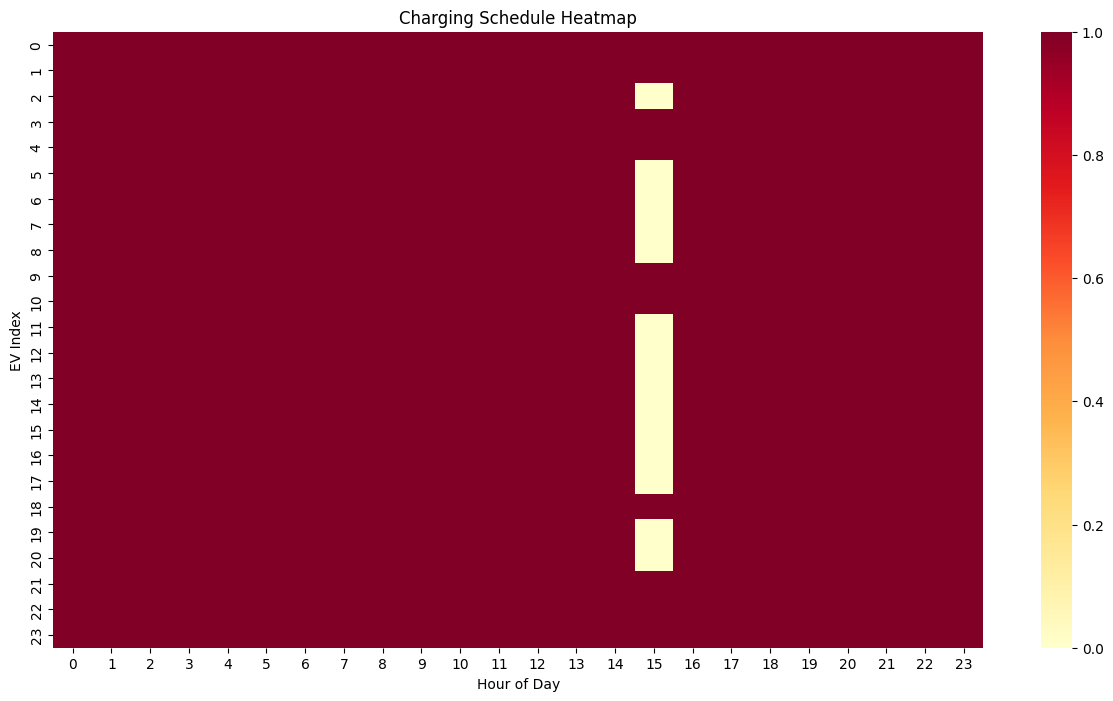

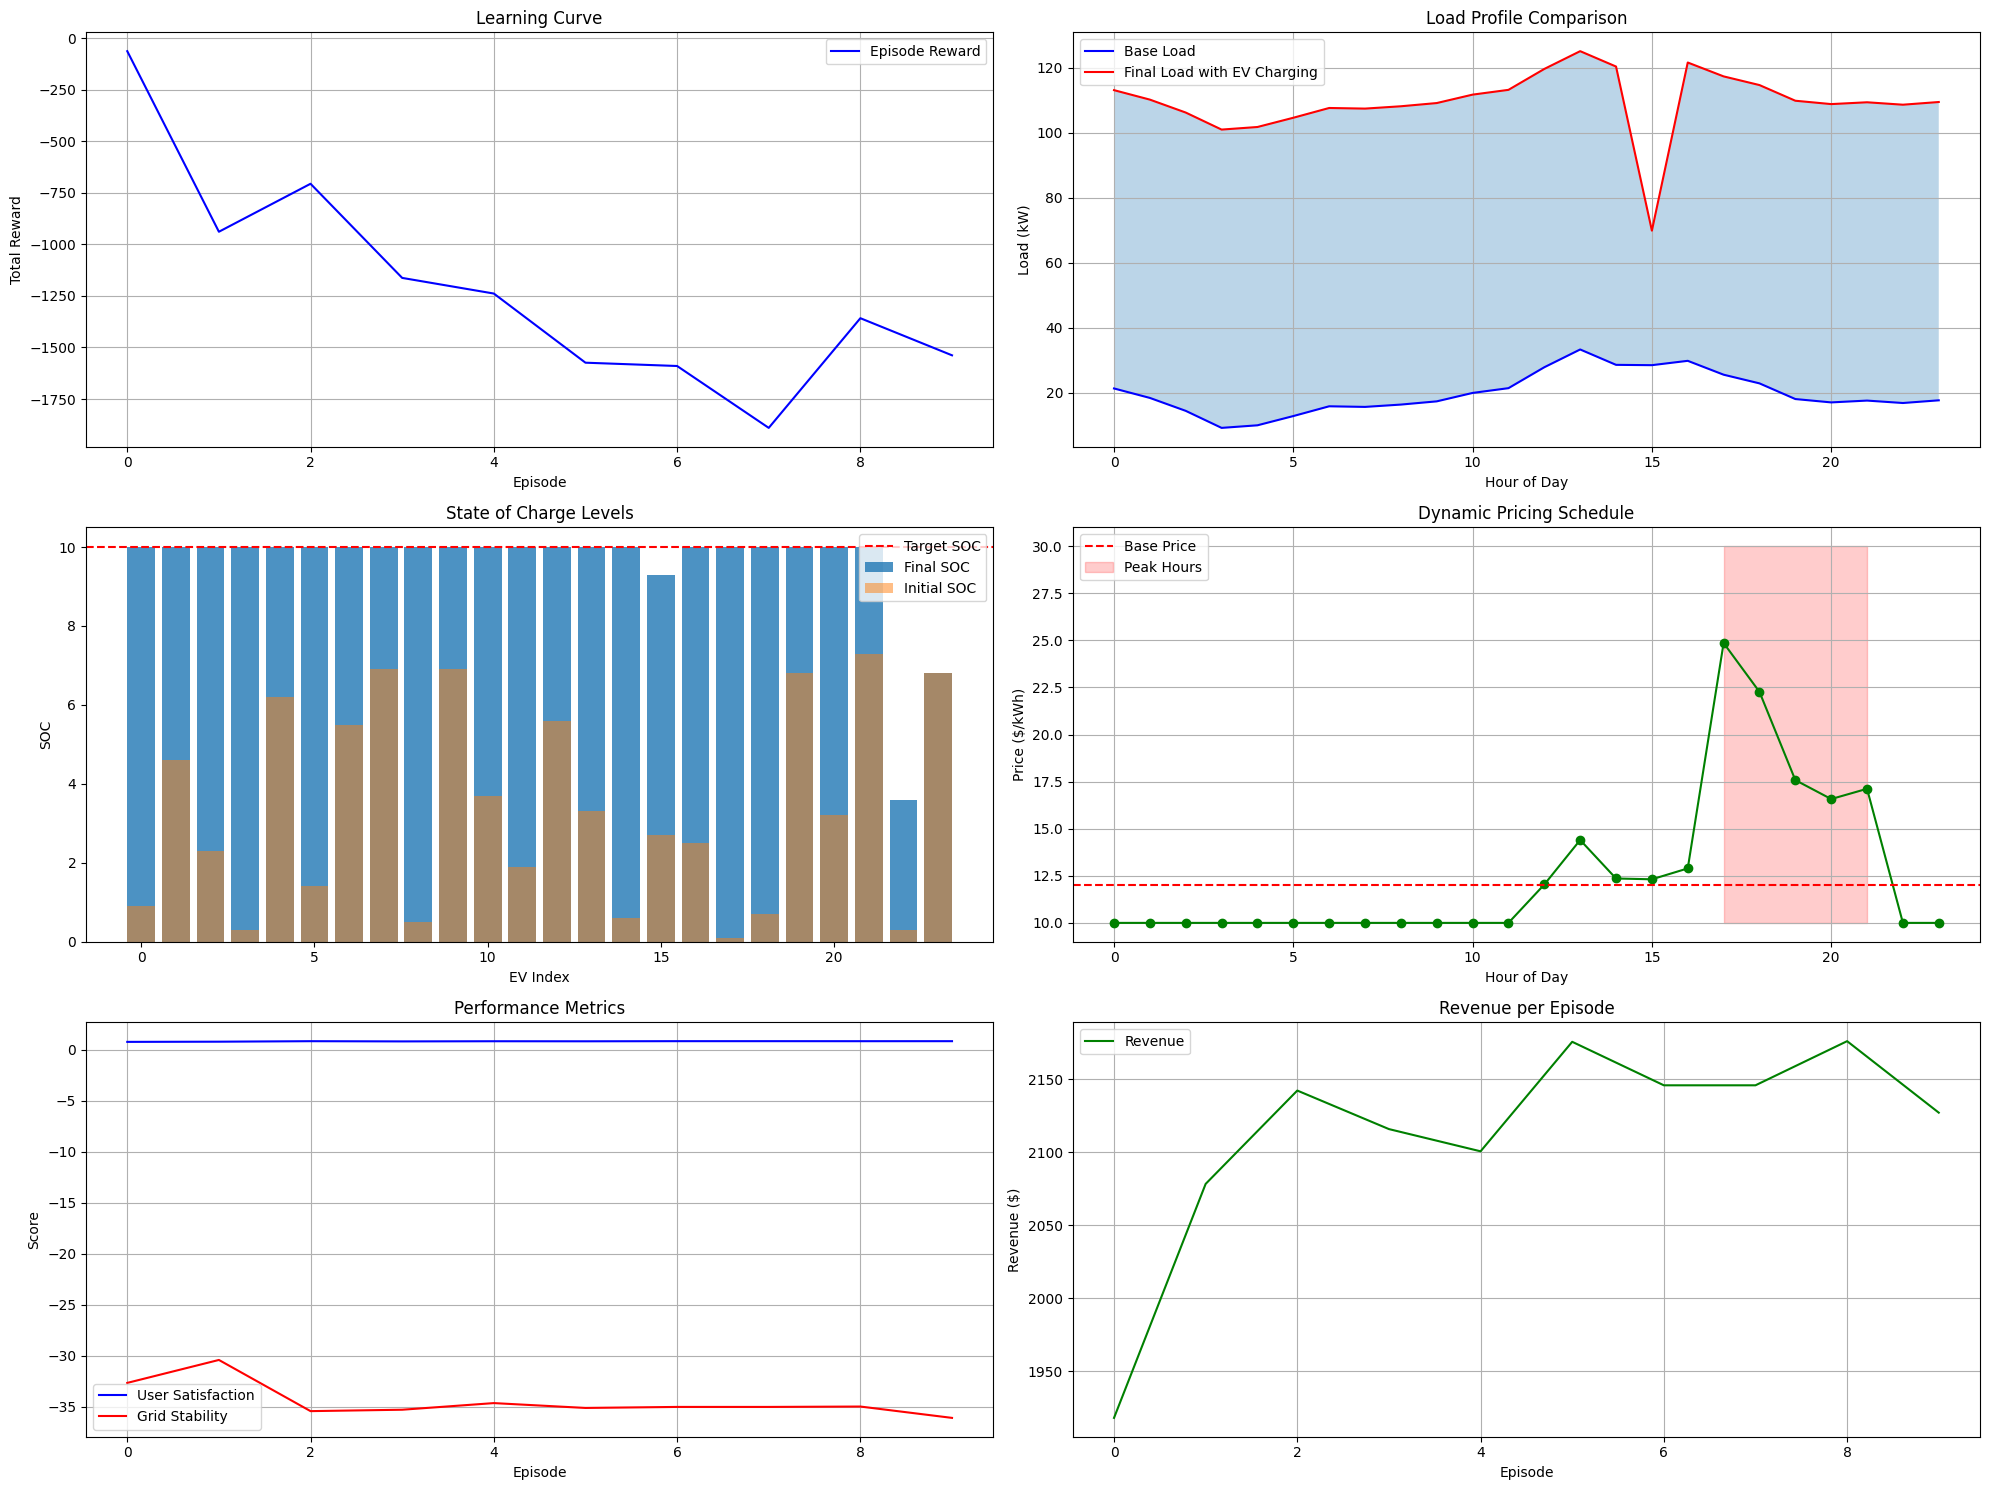

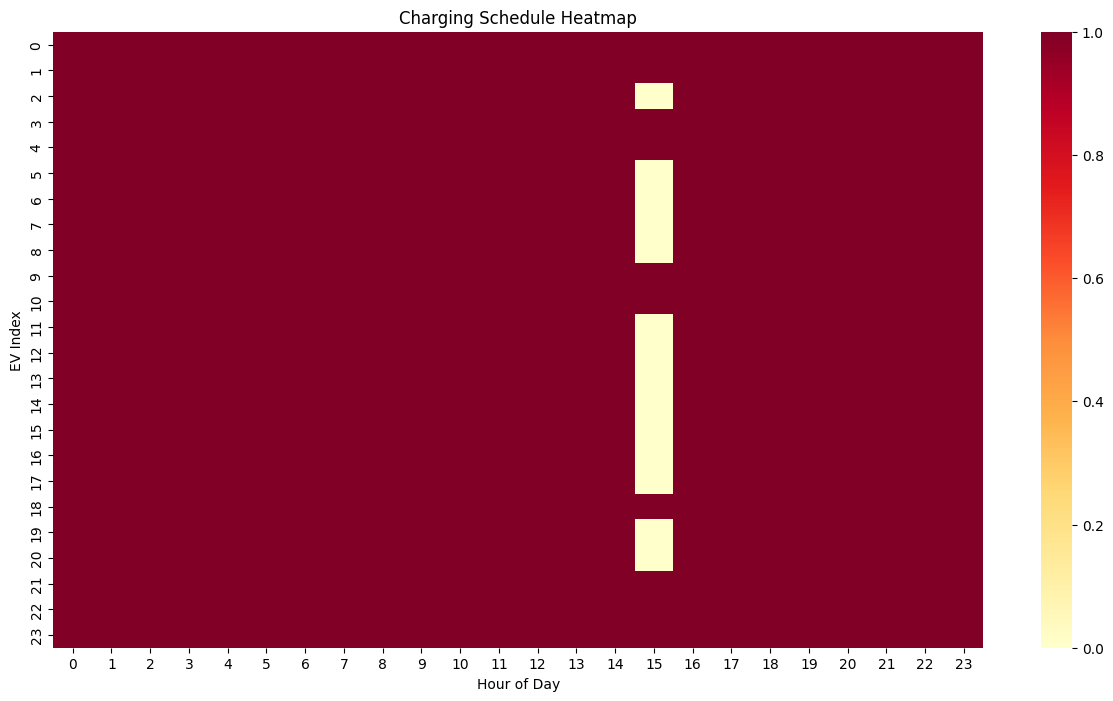


Final Results Summary:
Average Reward (last 5 episodes): -1589.98
Peak Load Reduction: -91.80 kW
Average SOC Achievement: 95.7%
Final Revenue: $2127.08
Average User Satisfaction: 0.84
Average Grid Stability: -36.10
Average Price per kWh: $12.60


In [15]:
def train_agent_with_monitoring():
    env = EVChargingEnvironment()
    state_size = len(env.reset())
    action_size = env.n_evs
    agent = DQLAgent(state_size, action_size)

    metrics = ChargingMetrics()
    episodes = 10
    batch_size = 8

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        episode_load_profile = load_profile.copy()
        charging_schedule = np.zeros((len(p_max), 24))

        while True:
            action = agent.act(state)
            next_state, reward, done = env.step(action)

            # Record charging actions
            for ev in range(env.n_evs):
                if action[ev]:
                    if env.current_time > 0:
                        charging_schedule[ev, env.current_time-1] = 1
                        episode_load_profile[env.current_time-1] += p_max[ev]

            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if done:
                print(f"\nEpisode: {episode + 1}/{episodes}")
                print(f"Total Reward: {total_reward:.2f}")
                print(f"Final Revenue: ${env.revenue:.2f}")
                print(f"Average User Satisfaction: {np.mean(env.user_satisfaction):.2f}")
                print(f"Average Grid Stability: {np.mean(env.grid_stability):.2f}")

                metrics.add_episode_metrics(
                    total_reward,
                    episode_load_profile,
                    env.current_soc,
                    charging_schedule,
                    env.prices,
                    env.user_satisfaction,
                    env.grid_stability,
                    env.revenue
                )

                if (episode + 1) % 5 == 0:
                    metrics.plot_metrics()
                break

            if len(agent.memory) > batch_size:
                agent.replay(batch_size)

    return agent, metrics

# Run training and display results
if __name__ == "__main__":
    trained_agent, training_metrics = train_agent_with_monitoring()

    # Final visualization
    training_metrics.plot_metrics()

    # Print final results summary
    final_results = {
        'episode_rewards': training_metrics.episode_rewards,
        'final_load_profile': training_metrics.load_profiles[-1],
        'final_soc_levels': training_metrics.final_soc_levels[-1],
        'final_charging_schedule': training_metrics.charging_schedules[-1],
        'final_prices': training_metrics.pricing_history[-1],
        'final_revenue': training_metrics.revenue_history[-1],
        'final_satisfaction': np.mean(training_metrics.user_satisfaction_history[-1]),
        'final_grid_stability': np.mean(training_metrics.grid_stability_history[-1])
    }

    print("\nFinal Results Summary:")
    print(f"Average Reward (last 5 episodes): {np.mean(training_metrics.episode_rewards[-5:]):.2f}")
    print(f"Peak Load Reduction: {(max(load_profile) - max(final_results['final_load_profile'])):.2f} kW")
    print(f"Average SOC Achievement: {np.mean(final_results['final_soc_levels'])/10*100:.1f}%")
    print(f"Final Revenue: ${final_results['final_revenue']:.2f}")
    print(f"Average User Satisfaction: {final_results['final_satisfaction']:.2f}")
    print(f"Average Grid Stability: {final_results['final_grid_stability']:.2f}")
    print(f"Average Price per kWh: ${np.mean(final_results['final_prices']):.2f}")

**2. Complete Code but with Certain Errors**

In [16]:
import numpy as np
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime, timedelta

# Original data arrays remain the same
load_profile = np.array([21.354, 18.44, 14.46, 9.22, 10.014, 12.858, 15.866, 15.676, 16.393,
                        17.383, 19.976, 21.445, 27.88, 33.35, 28.618, 28.519, 29.857, 25.588,
                        22.918, 18.096, 17.061, 17.621, 16.875, 17.703])

t_arr = np.array([4, 4, 5, 5, 7, 8, 8, 8, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14])
t_dep = np.array([8, 6, 9, 9, 10, 11, 11, 10, 16, 20, 20, 21, 21, 22, 21, 19, 23, 23, 23, 20, 24, 23, 20, 19])
soc_0 = np.array([0.9, 4.6, 2.3, 0.3, 6.2, 1.4, 5.5, 6.9, 0.5, 6.9, 3.7, 1.9, 5.6, 3.3, 0.6, 2.7, 2.5, 0.1, 0.7, 6.8, 3.2, 7.3, 0.3, 6.8])
soc_d = soc_0 * 0 + 10
p_max = np.array([3.3, 7.5, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 3.3, 7.5, 3.3, 3.3, 3.3, 3.3, 3.3])
alpha_avg = 0.95

# New constants for pricing and scheduling
PEAK_HOURS = set(range(17, 22))  # 5 PM to 9 PM
BASE_PRICE = 10.0  # Base price per kWh
PEAK_PRICE_FACTOR = 1.5
MIN_PRICE = 8.0
MAX_PRICE = 25.0

In [17]:
class EVChargingEnvironment:
    def __init__(self, load_profile=load_profile, t_arr=t_arr, t_dep=t_dep,
                 soc_0=soc_0, soc_d=soc_d, p_max=p_max, alpha_avg=alpha_avg):
        """Initialize the EV charging environment"""
        self.load_profile = load_profile
        self.t_arr = t_arr
        self.t_dep = t_dep
        self.soc_0 = soc_0
        self.soc_d = soc_d
        self.p_max = p_max
        self.alpha_avg = alpha_avg
        self.T = len(load_profile)
        self.n_evs = len(p_max)

        # Additional tracking variables
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0

        # Initialize state variables
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)

    def reset(self):
        """Reset the environment to initial state"""
        self.current_time = 0
        self.current_soc = self.soc_0.copy()
        self.charging_status = np.zeros(self.n_evs)
        self.waiting_times = np.zeros(self.n_evs)
        self.prices = np.zeros(24)
        self.user_satisfaction = []
        self.grid_stability = []
        self.revenue = 0.0
        return self._get_state()

    def _get_state(self):
        """Get current state representation"""
        return np.concatenate([
            [self.current_time],
            self.current_soc,
            self.charging_status,
            self.t_arr,
            self.t_dep,
            [self.prices[min(self.current_time, self.T-1)]],
            self.waiting_times
        ])

    def calculate_price(self, current_load, time_of_day):
        """Calculate dynamic pricing based on load and time of day"""
        base_price = BASE_PRICE

        # Higher prices during peak hours
        peak_factor = PEAK_PRICE_FACTOR if time_of_day in PEAK_HOURS else 1.0

        # Load-based pricing
        load_factor = current_load / max(self.load_profile)
        load_factor = min(2.0, load_factor)  # Cap the load factor

        # Time-of-day pricing
        time_factor = 1.0
        if time_of_day in range(9, 17):  # Business hours
            time_factor = 1.2
        elif time_of_day in PEAK_HOURS:  # Peak hours
            time_factor = 1.5

        price = base_price * peak_factor * load_factor * time_factor
        return np.clip(price, MIN_PRICE, MAX_PRICE)

    def calculate_user_satisfaction(self):
        """Calculate user satisfaction based on charging completion and waiting time"""
        satisfaction = 0
        active_evs = 0

        for ev in range(self.n_evs):
            if self.current_time >= self.t_arr[ev]:
                active_evs += 1

                # Charging progress satisfaction
                progress = min(1.0, self.current_soc[ev] / self.soc_d[ev])

                # Waiting time dissatisfaction
                waiting_penalty = 0.05 * self.waiting_times[ev]

                # Price satisfaction (lower prices = higher satisfaction)
                price_satisfaction = 1.0 - (self.prices[min(self.current_time, self.T-1)] - MIN_PRICE) / (MAX_PRICE - MIN_PRICE)

                ev_satisfaction = (0.5 * progress + 0.3 * (1 - waiting_penalty) + 0.2 * price_satisfaction)
                satisfaction += max(0, ev_satisfaction)

        return satisfaction / max(1, active_evs)

    def calculate_grid_impact(self):
        """Calculate impact on grid stability"""
        time_index = min(self.current_time, self.T - 1)
        total_load = self.load_profile[time_index] + np.sum(self.charging_status * self.p_max)
        peak_increase = max(0, total_load - max(self.load_profile))

        # Calculate load variance for the current hour
        start_idx = max(0, time_index - 3)
        end_idx = min(time_index + 1, self.T)
        recent_loads = self.load_profile[start_idx:end_idx]
        load_variance = np.var(recent_loads)

        return -peak_increase - 0.1 * load_variance

    def step(self, action):
        """Execute one time step within the environment"""
        reward = 0
        done = False
        time_index = min(self.current_time, self.T - 1)
        current_load = self.load_profile[time_index]

        # Calculate current price
        current_price = self.calculate_price(current_load, time_index)
        self.prices[time_index] = current_price

        total_charging_load = 0

        # Apply charging actions and calculate rewards
        for ev in range(self.n_evs):
            if action[ev] and self.current_time >= self.t_arr[ev] and self.current_time < self.t_dep[ev]:
                # Check if EV needs charging and hasn't reached target SOC
                if self.current_soc[ev] < self.soc_d[ev]:
                    charging_amount = min(
                        self.p_max[ev],
                        self.soc_d[ev] - self.current_soc[ev]  # Only charge what's needed
                    )

                    self.current_soc[ev] += charging_amount
                    self.charging_status[ev] = 1
                    total_charging_load += charging_amount

                    # Calculate reward components
                    charging_progress = (self.current_soc[ev] - self.soc_0[ev]) / (self.soc_d[ev] - self.soc_0[ev])
                    charging_progress = min(1.0, charging_progress)  # Cap at 100%

                    # Update revenue
                    self.revenue += current_price * charging_amount

                    # Reward for proper charging
                    reward += 50 * charging_progress

                # Penalty for unnecessary charging
                elif self.current_soc[ev] >= self.soc_d[ev]:
                    reward -= 100

            # Update waiting times only if EV needs charging
            if self.current_time >= self.t_arr[ev] and self.current_soc[ev] < self.soc_d[ev]:
                self.waiting_times[ev] += 1
                reward -= 0.5 * self.waiting_times[ev]  # Small penalty for waiting

        # Grid stability reward/penalty
        total_load = current_load + total_charging_load
        if total_load > max(self.load_profile):
            reward -= 200 * (total_load - max(self.load_profile)) / max(self.load_profile)

        # Load balancing reward
        load_variance = np.var([total_load, current_load])
        reward -= 50 * load_variance / max(self.load_profile)

        # Time management reward
        if self.current_time in PEAK_HOURS:
            reward -= 100 * (total_charging_load / sum(self.p_max))

        self.current_time += 1
        if self.current_time >= self.T:
            done = True

            # Final state rewards/penalties
            for ev in range(self.n_evs):
                if self.current_soc[ev] < self.soc_d[ev]:
                    reward -= 500  # Heavy penalty for not reaching target SOC
                elif self.current_soc[ev] > self.soc_d[ev] * 1.1:  # 10% tolerance
                    reward -= 300  # Penalty for overcharging

        # Store metrics
        self.user_satisfaction.append(self.calculate_user_satisfaction())
        self.grid_stability.append(self.calculate_grid_impact())

        return self._get_state(), reward, done

In [18]:
class ChargingMetrics:
    def __init__(self):
        self.episode_rewards = []
        self.load_profiles = []
        self.final_soc_levels = []
        self.charging_schedules = []
        self.pricing_history = []
        self.user_satisfaction_history = []
        self.grid_stability_history = []
        self.revenue_history = []

    def add_episode_metrics(self, total_reward, load_profile, final_soc, charging_schedule,
                          prices, user_satisfaction, grid_stability, revenue):
        self.episode_rewards.append(total_reward)
        self.load_profiles.append(load_profile)
        self.final_soc_levels.append(final_soc)
        self.charging_schedules.append(charging_schedule)
        self.pricing_history.append(prices)
        self.user_satisfaction_history.append(user_satisfaction)
        self.grid_stability_history.append(grid_stability)
        self.revenue_history.append(revenue)

    def plot_metrics(self):
        plt.figure(figsize=(20, 15))

        # Plot 1: Learning Curve
        plt.subplot(3, 2, 1)
        plt.plot(self.episode_rewards)
        plt.title('Learning Curve')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.grid(True)

        # Plot 2: Load Profile
        plt.subplot(3, 2, 2)
        base_load = load_profile
        final_load = self.load_profiles[-1]
        hours = range(24)
        plt.plot(hours, base_load, 'b-', label='Base Load')
        plt.plot(hours, final_load, 'r-', label='Final Load with EV Charging')
        plt.fill_between(hours, base_load, final_load, alpha=0.3)
        plt.title('Load Profile Comparison')
        plt.xlabel('Hour of Day')
        plt.ylabel('Load (kW)')
        plt.legend()
        plt.grid(True)

        # Plot 3: SOC Levels
        plt.subplot(3, 2, 3)
        final_soc = self.final_soc_levels[-1]
        x = range(len(final_soc))
        plt.bar(x, final_soc, alpha=0.8, label='Final SOC')
        plt.bar(x, soc_0, alpha=0.5, label='Initial SOC')
        plt.axhline(y=10, color='r', linestyle='--', label='Target SOC')
        plt.title('State of Charge Levels')
        plt.xlabel('EV Index')
        plt.ylabel('SOC')
        plt.legend()

        # Plot 4: Dynamic Pricing
        plt.subplot(3, 2, 4)
        plt.plot(hours, self.pricing_history[-1], 'g-', marker='o')
        plt.axhline(y=BASE_PRICE, color='r', linestyle='--', label='Base Price')
        plt.title('Dynamic Pricing Schedule')
        plt.xlabel('Hour of Day')
        plt.ylabel('Price ($/kWh)')
        plt.grid(True)

        # Plot 5: User Satisfaction and Grid Stability
        plt.subplot(3, 2, 5)
        plt.plot(self.user_satisfaction_history[-1], 'b-', label='User Satisfaction')
        plt.plot(self.grid_stability_history[-1], 'r-', label='Grid Stability')
        plt.title('Performance Metrics')
        plt.xlabel('Time Step')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # Plot 6: Revenue Trend
        plt.subplot(3, 2, 6)
        plt.plot(self.revenue_history, 'g-')
        plt.title('Revenue per Episode')
        plt.xlabel('Episode')
        plt.ylabel('Revenue ($)')
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # Additional Heatmap for Charging Schedule
        plt.figure(figsize=(15, 8))
        sns.heatmap(self.charging_schedules[-1],
                   cmap='YlOrRd',
                   xticklabels=range(24),
                   yticklabels=range(len(p_max)))
        plt.title('Charging Schedule Heatmap')
        plt.xlabel('Hour of Day')
        plt.ylabel('EV Index')
        plt.show()

In [19]:
def train_agent_with_monitoring():
    env = EVChargingEnvironment(load_profile, t_arr, t_dep, soc_0, soc_d, p_max, alpha_avg)
    state_size = len(env.reset())
    action_size = env.n_evs
    agent = DQLAgent(state_size, action_size)

    metrics = ChargingMetrics()
    episodes = 10
    batch_size = 8

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        episode_load_profile = load_profile.copy()
        charging_schedule = np.zeros((len(p_max), 24))

        while True:
            action = agent.act(state)
            next_state, reward, done = env.step(action)

            # Record charging actions
            for ev in range(env.n_evs):
                if action[ev]:
                    if env.current_time > 0:
                        charging_schedule[ev, env.current_time-1] = 1
                        episode_load_profile[env.current_time-1] += p_max[ev]

            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if done:
                print(f"\nEpisode: {episode + 1}/{episodes}")
                print(f"Total Reward: {total_reward:.2f}")
                print(f"Final Revenue: ${env.revenue:.2f}")
                print(f"Average User Satisfaction: {np.mean(env.user_satisfaction):.2f}")
                print(f"Average Grid Stability: {np.mean(env.grid_stability):.2f}")

                metrics.add_episode_metrics(
                    total_reward,
                    episode_load_profile,
                    env.current_soc,
                    charging_schedule,
                    env.prices,
                    env.user_satisfaction,
                    env.grid_stability,
                    env.revenue
                )

                if (episode + 1) % 5 == 0:
                    metrics.plot_metrics()
                break

            if len(agent.memory) > batch_size:
                agent.replay(batch_size)

    return agent, metrics


Episode: 1/10
Total Reward: -5239.04
Final Revenue: $1436.01
Average User Satisfaction: 0.81
Average Grid Stability: -40.64

Episode: 2/10
Total Reward: -7390.77
Final Revenue: $1595.73
Average User Satisfaction: 0.85
Average Grid Stability: -42.64

Episode: 3/10
Total Reward: -3397.04
Final Revenue: $1685.11
Average User Satisfaction: 0.84
Average Grid Stability: -41.68

Episode: 4/10
Total Reward: -9581.70
Final Revenue: $1552.08
Average User Satisfaction: 0.85
Average Grid Stability: -42.88

Episode: 5/10
Total Reward: -9759.95
Final Revenue: $1563.85
Average User Satisfaction: 0.88
Average Grid Stability: -43.46


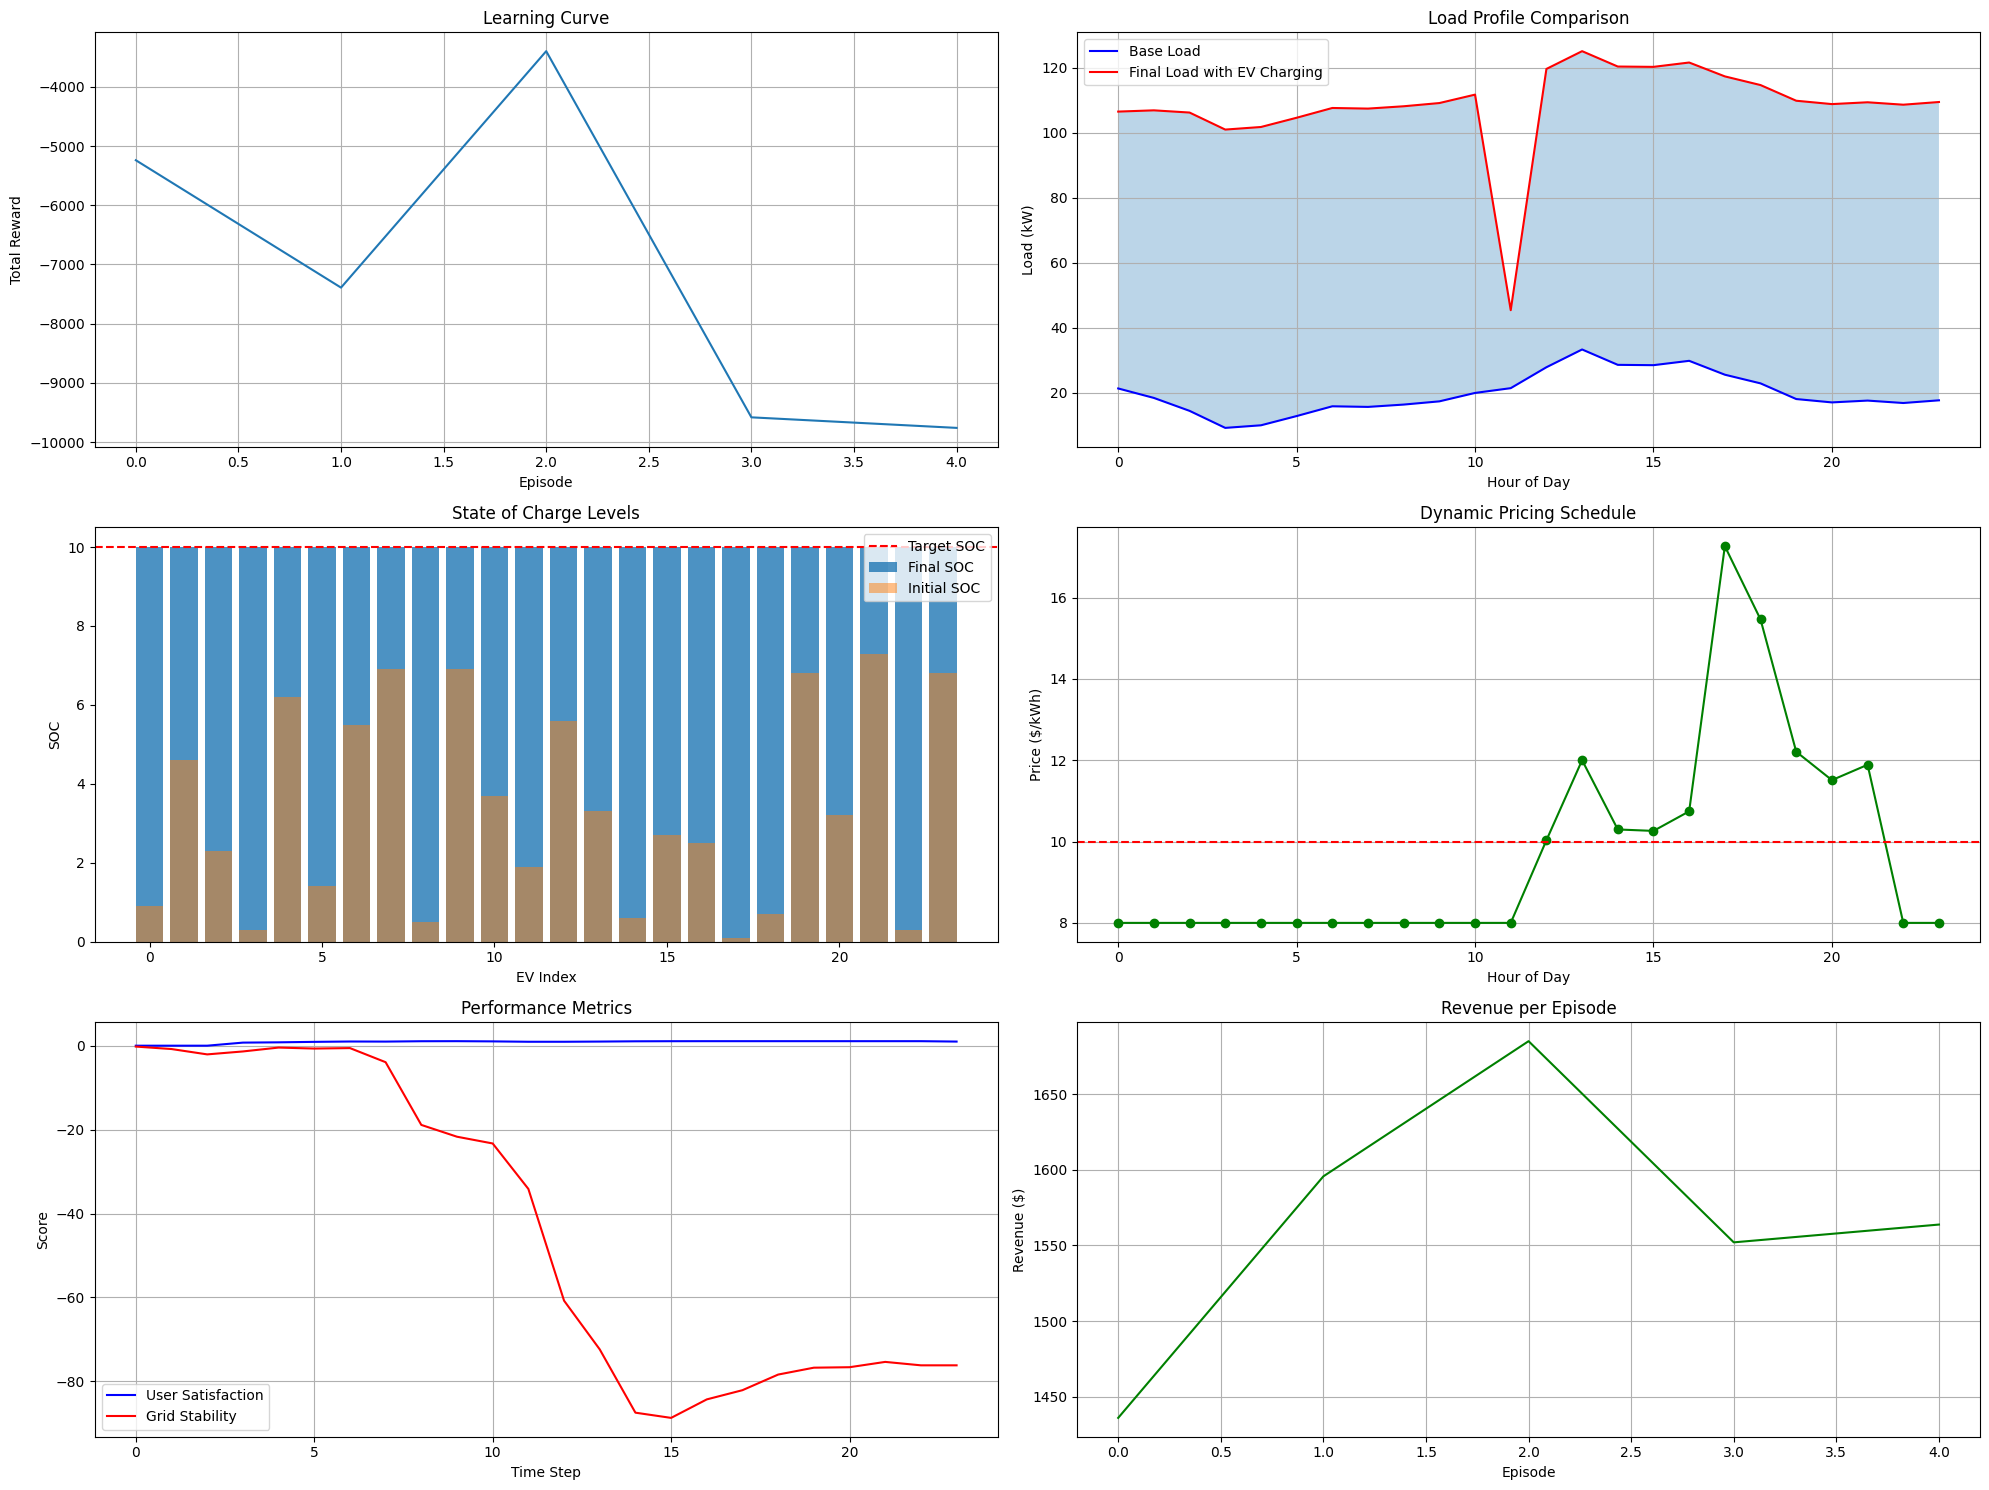

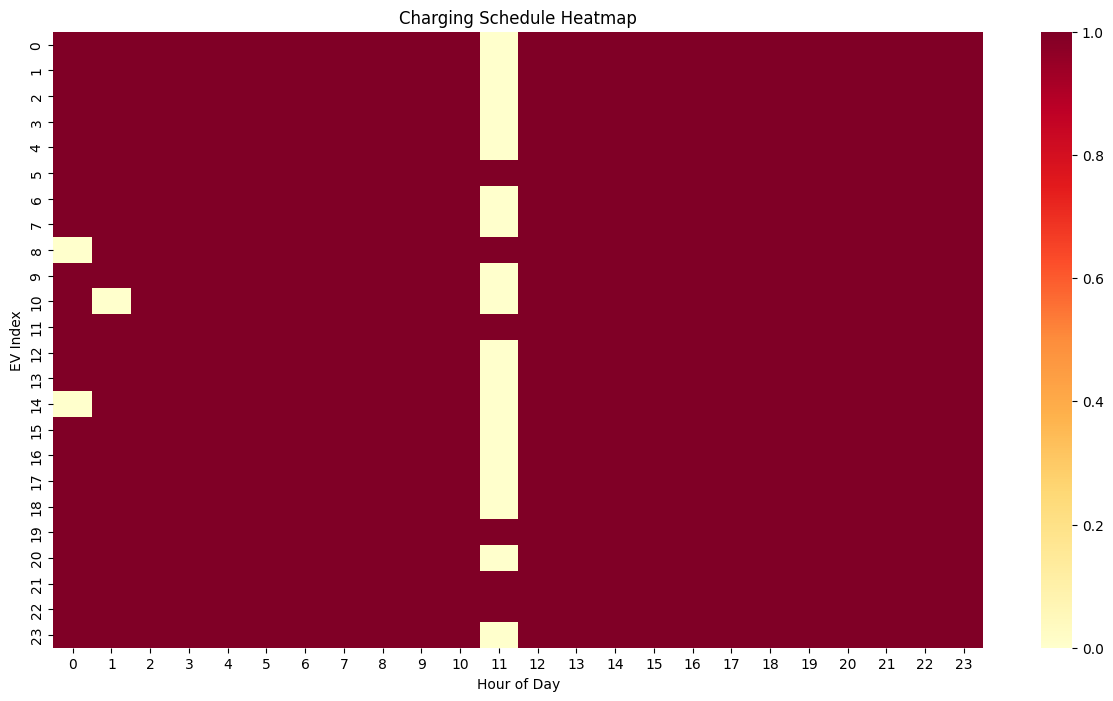


Episode: 6/10
Total Reward: -8849.19
Final Revenue: $1565.87
Average User Satisfaction: 0.88
Average Grid Stability: -43.46

Episode: 7/10
Total Reward: -8582.06
Final Revenue: $1577.47
Average User Satisfaction: 0.87
Average Grid Stability: -42.91

Episode: 8/10
Total Reward: -9759.95
Final Revenue: $1563.85
Average User Satisfaction: 0.88
Average Grid Stability: -43.46

Episode: 9/10
Total Reward: -9759.95
Final Revenue: $1563.85
Average User Satisfaction: 0.88
Average Grid Stability: -43.46

Episode: 10/10
Total Reward: -9064.36
Final Revenue: $1584.06
Average User Satisfaction: 0.88
Average Grid Stability: -43.46


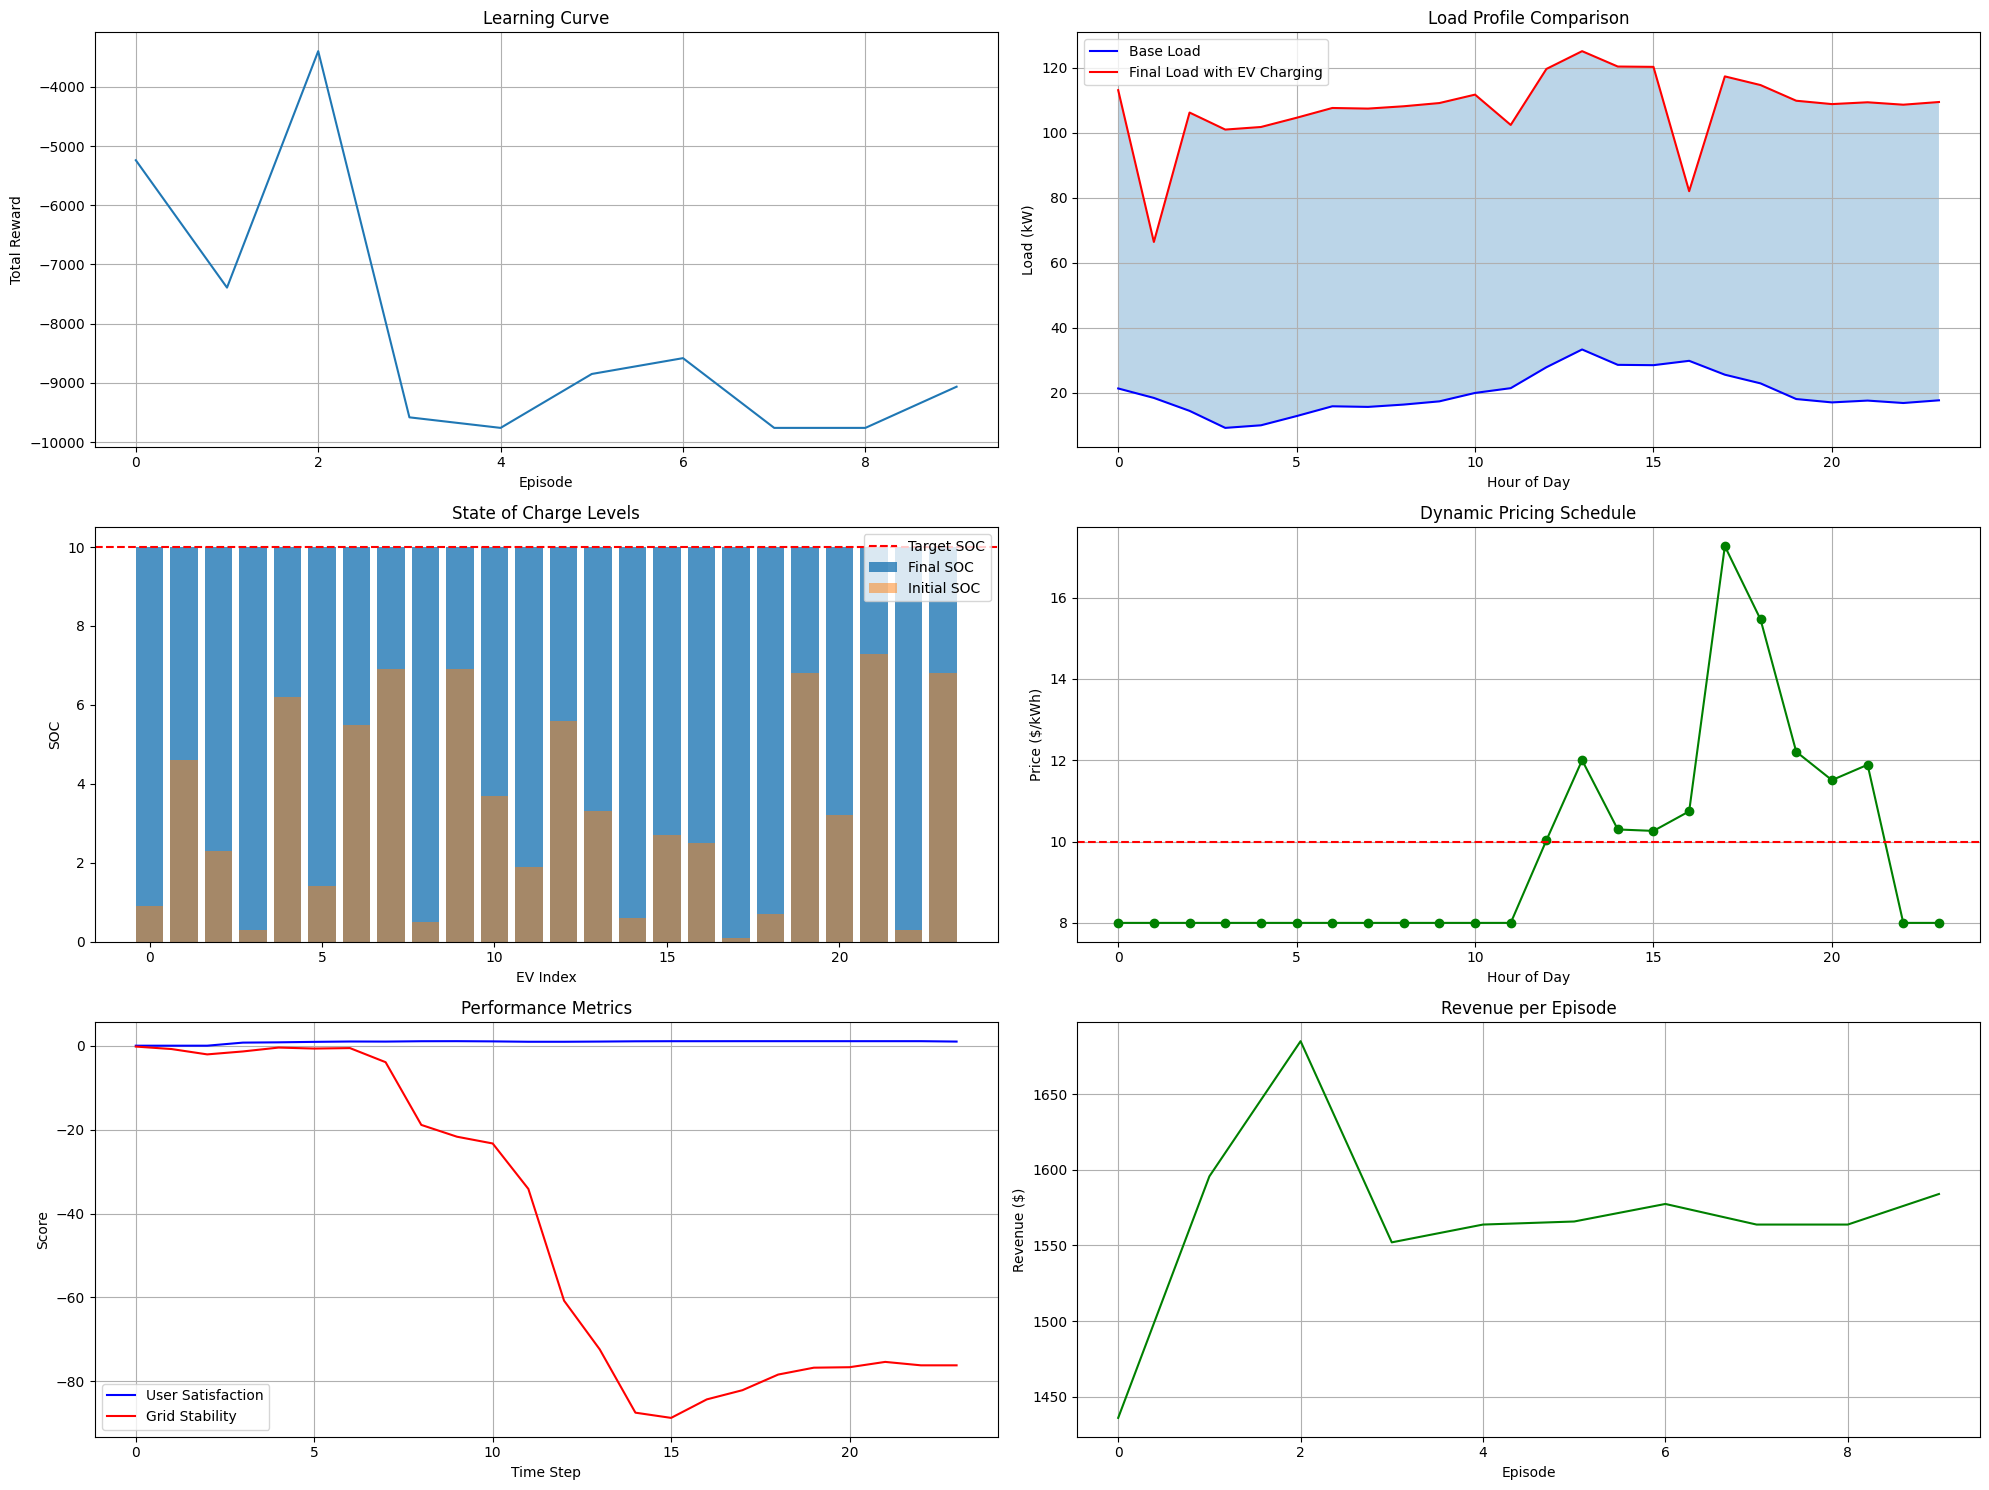

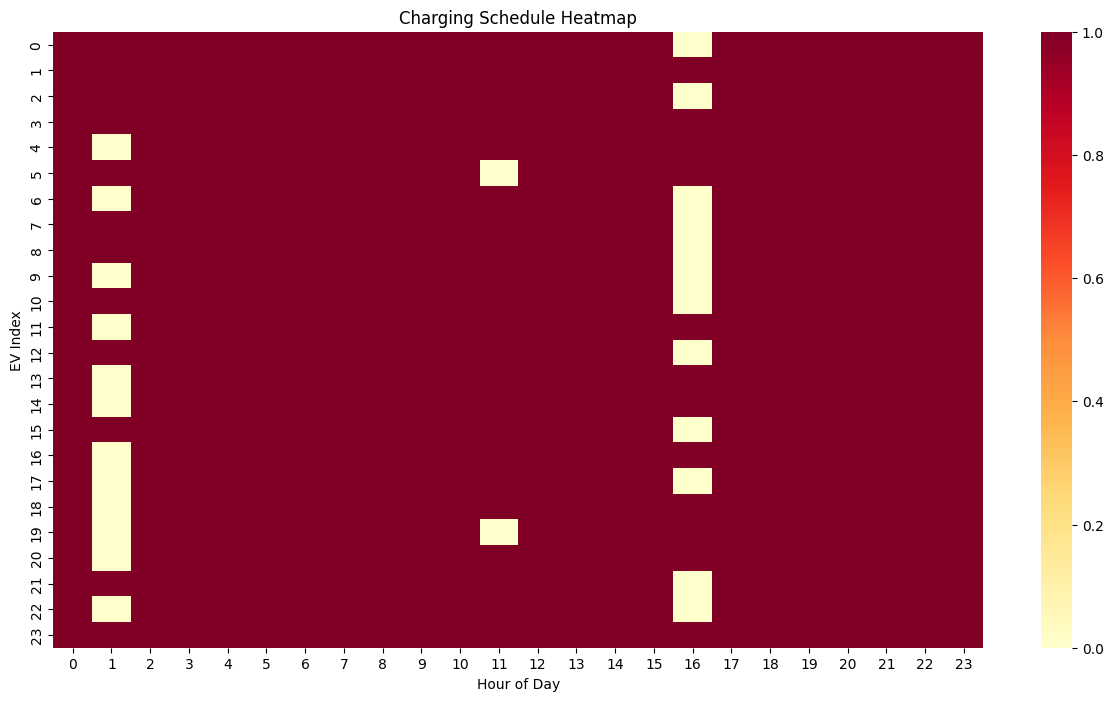

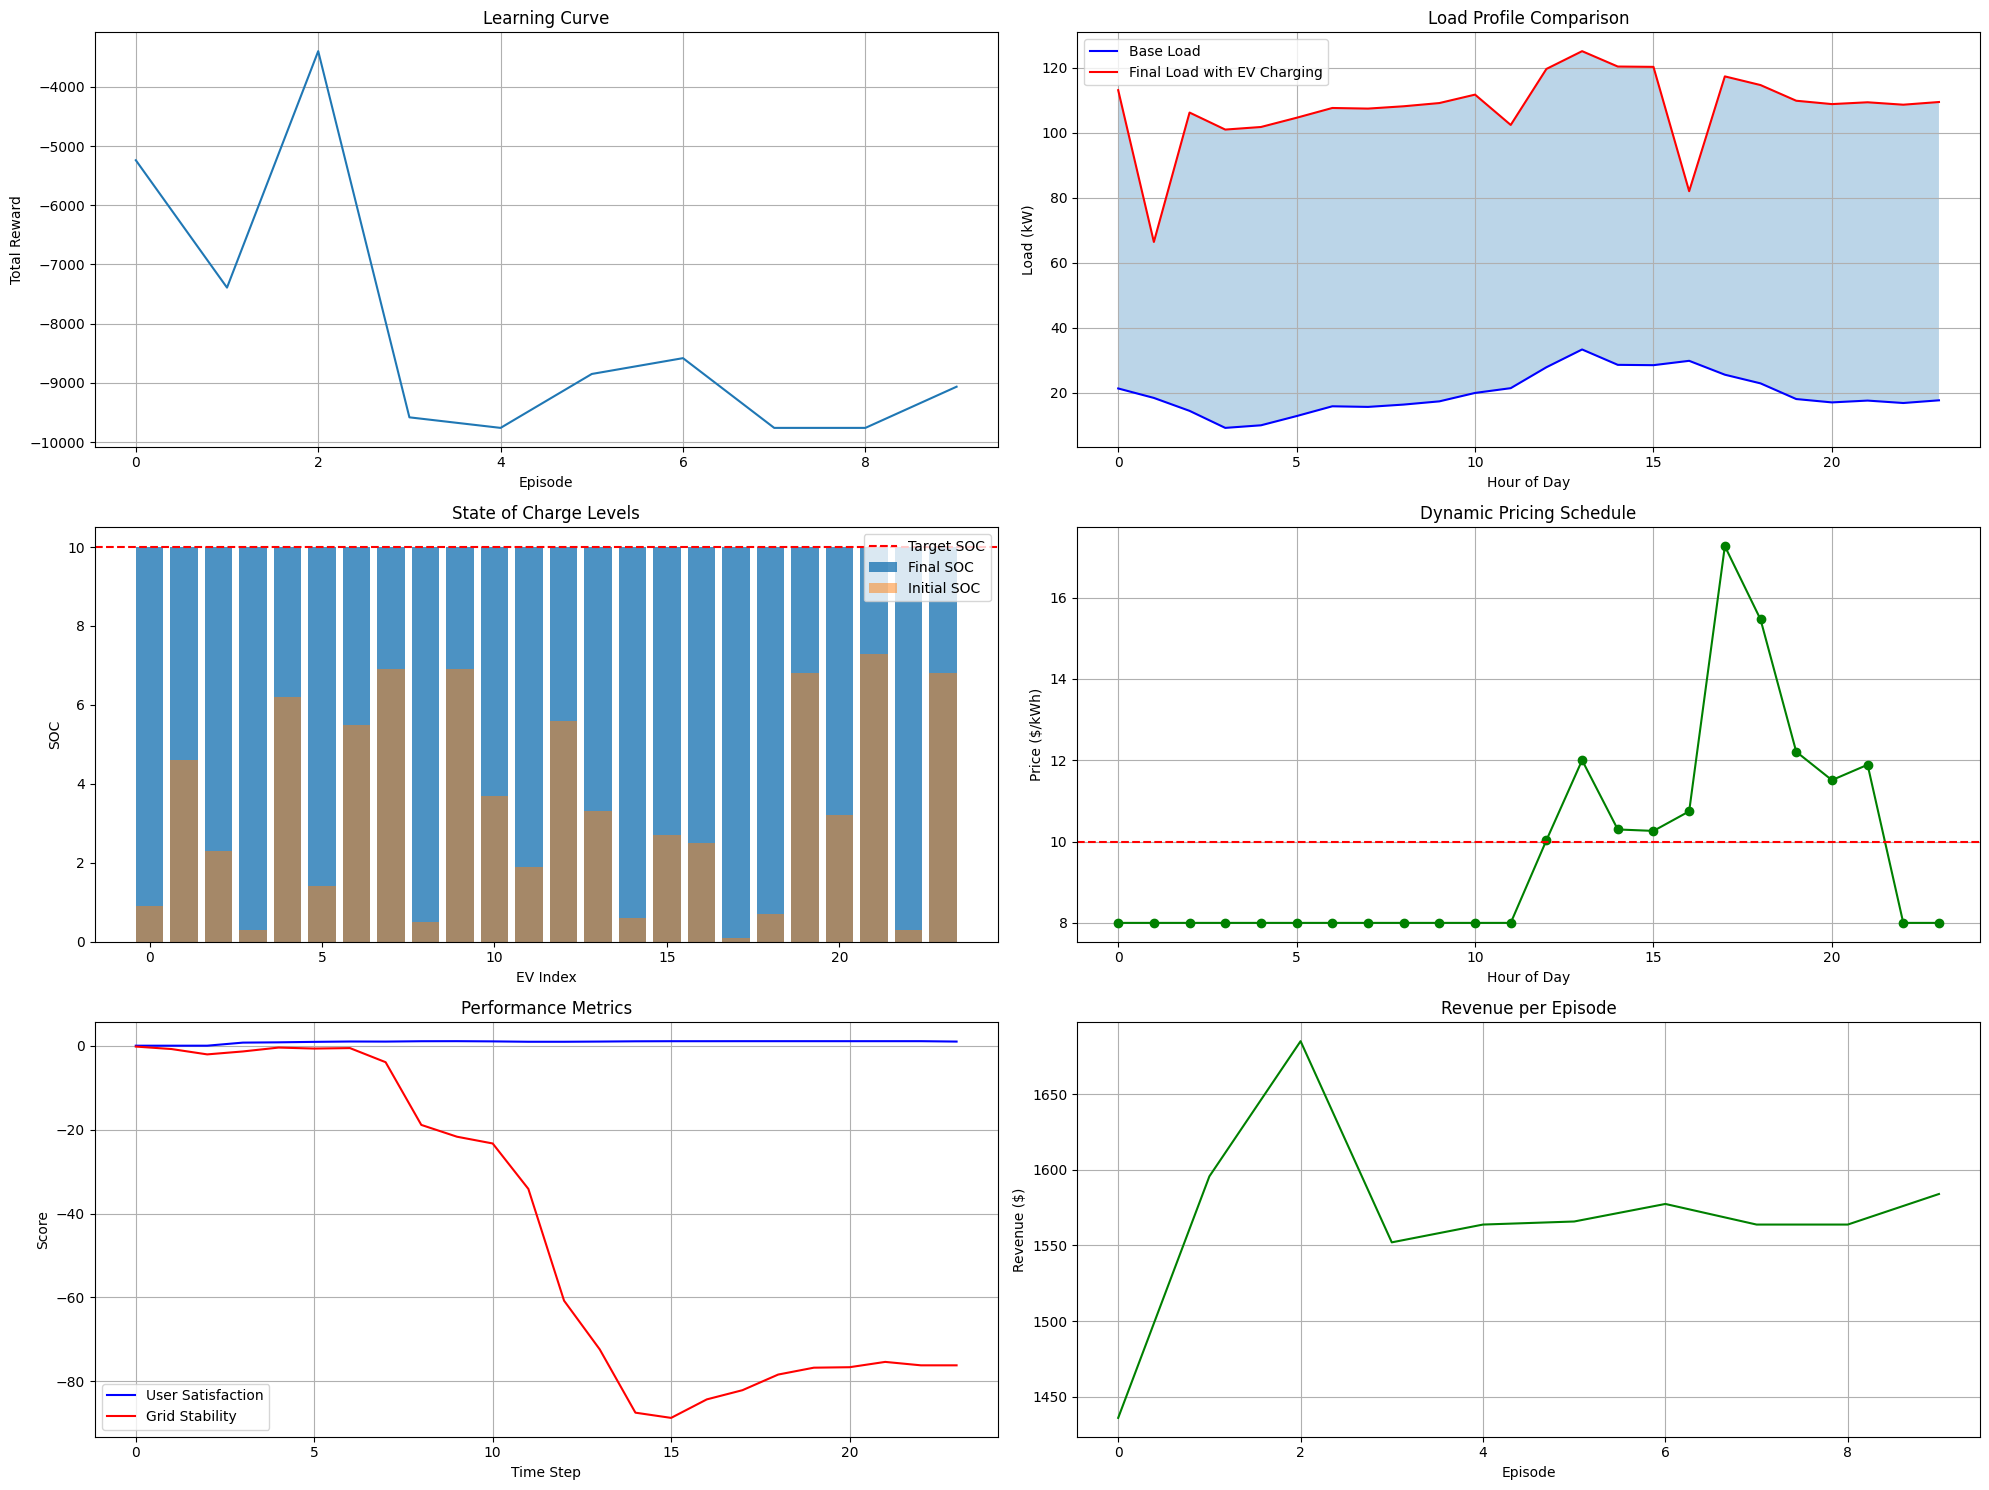

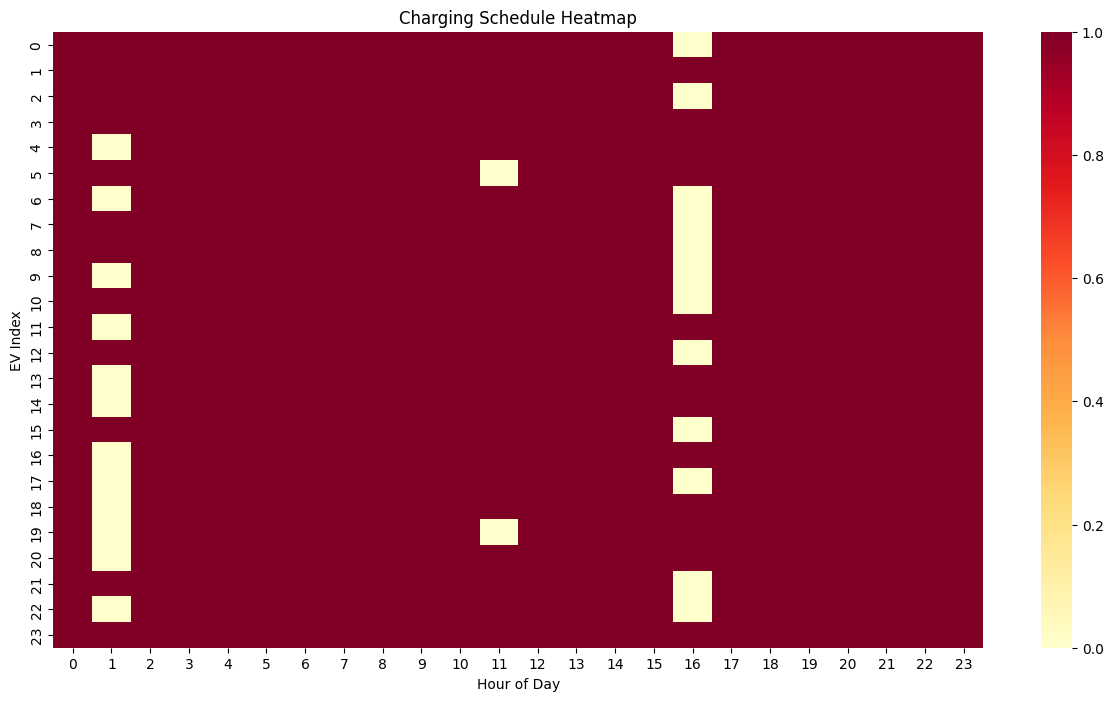


Final Results Summary:
Average Reward (last 5 episodes): -9203.10
Peak Load Reduction: -91.80 kW
Average SOC Achievement: 100.0%
Final Revenue: $1584.06
Average User Satisfaction: 0.88
Average Grid Stability: -43.46
Average Price per kWh: $9.74


In [20]:
# Run training
trained_agent, training_metrics = train_agent_with_monitoring()

# Final visualization
training_metrics.plot_metrics()

# Final results summary
final_results = {
    'episode_rewards': training_metrics.episode_rewards,
    'final_load_profile': training_metrics.load_profiles[-1],
    'final_soc_levels': training_metrics.final_soc_levels[-1],
    'final_charging_schedule': training_metrics.charging_schedules[-1],
    'final_prices': training_metrics.pricing_history[-1],
    'final_revenue': training_metrics.revenue_history[-1],
    'final_satisfaction': np.mean(training_metrics.user_satisfaction_history[-1]),
    'final_grid_stability': np.mean(training_metrics.grid_stability_history[-1])
}

print("\nFinal Results Summary:")
print(f"Average Reward (last 5 episodes): {np.mean(training_metrics.episode_rewards[-5:]):.2f}")
print(f"Peak Load Reduction: {(max(load_profile) - max(final_results['final_load_profile'])):.2f} kW")
print(f"Average SOC Achievement: {np.mean(final_results['final_soc_levels'])/10*100:.1f}%")
print(f"Final Revenue: ${final_results['final_revenue']:.2f}")
print(f"Average User Satisfaction: {final_results['final_satisfaction']:.2f}")
print(f"Average Grid Stability: {final_results['final_grid_stability']:.2f}")
print(f"Average Price per kWh: ${np.mean(final_results['final_prices']):.2f}")

# 新段落

# Nova seção

### Como Usar este Notebook

Este notebook está dividido em seções para facilitar a navegação e a execução do código.

*   **Execução de Células:** Para executar uma célula, selecione-a e pressione `Shift + Enter` ou clique no botão 'Reproduzir' ao lado da célula.
*   **Fluxo de Trabalho:** Recomenda-se executar as células sequencialmente, de cima para baixo, para garantir que todas as dependências e variáveis sejam carregadas corretamente.
*   **Modificação de Código:** Sinta-se à vontade para modificar o código dentro das células para experimentar diferentes parâmetros ou funcionalidades. Lembre-se de reexecutar as células modificadas.
*   **Saídas e Visualizações:** As saídas e os gráficos serão exibidos diretamente abaixo das células de código após a execução.
*   **Interatividade:** Se houver prompts interativos, siga as instruções fornecidas na saída da célula.

---